In [1]:
import sys
import os
import gc
import copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Corrfunc projected correlation function
from Corrfunc.theory.wp import wp as corrfunc_wp

LOCAL_RUN = False   # ← toggle this

if LOCAL_RUN:
    # Paths for local testing — update to wherever your local
    # mock catalogue lives. Pegasus paths are preserved below.
    POSTPROCESS_PATH = Path("/path/to/sahyadri-sandbox/scripts/post-process")
    HALO_CAT_M200B   = Path("/path/to/mock_v2_M200b_corrected.fits")
else:
    POSTPROCESS_PATH = Path(
        "/mnt/home/project/cgowari.aditya/sahyadri-codes/"
        "sahyadri-sandbox/scripts/post-process"
    )
    HALO_CAT_M200B = Path(
        "/mnt/home/project/cgowari.aditya/sahyadri-codes/"
        "mock_v2_M200b_corrected.fits"
    )

        
MR_THRESH  = -18.0   # Luminosity threshold (r-band absolute magnitude)
SEED       = 10      # Global RNG seed — shared by baseline + all perturbation pairs
PIMAX      = 40.0    # Line-of-sight integration limit for wp [h⁻¹ Mpc]
N_RP       = 50      # Number of rp bins
RP_MIN     = 0.5     # Minimum rp [h⁻¹ Mpc]
RP_MAX     = 30.0    # Maximum rp [h⁻¹ Mpc]
NTHREADS   = 4       # Corrfunc threads
MASSDEF    = 'm200b' # Halo mass definition used throughout
OUTPUT_DIR = Path('results')

# Sahyadri simulation identifiers (verbatim from run_pipeline.py)
SIM_STEM = 'sahyadri/default2048'
REAL     = 1
SNAP     = 82

# Validated simulation header values — used in Ch 3 assert checks
EXPECTED_N_HALOS = 343_275
EXPECTED_LBOX    = 200.0    # h⁻¹ Mpc
EXPECTED_OMEGA_M = 0.3137721


np.random.seed(SEED)


OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'figure.dpi':       120,
})


print("Environment check")
print(f"  numpy         : {np.__version__}")
print(f"  matplotlib    : {mpl.__version__}")
print(f"  MR_THRESH     : {MR_THRESH}")
print(f"  SEED          : {SEED}")
print(f"  PIMAX         : {PIMAX} h⁻¹ Mpc")
print(f"  rp bins       : {N_RP} in [{RP_MIN}, {RP_MAX}] h⁻¹ Mpc")
print(f"  OUTPUT_DIR    : {OUTPUT_DIR.resolve()}")
print(f"  HALO_CAT_M200B: {HALO_CAT_M200B}")
print(f"  LOCAL_RUN     : {LOCAL_RUN}")
print()
print("✓ Chapter 2 complete — environment and configuration confirmed.")

Environment check
  numpy         : 1.23.5
  matplotlib    : 3.7.0
  MR_THRESH     : -18.0
  SEED          : 10
  PIMAX         : 40.0 h⁻¹ Mpc
  rp bins       : 50 in [0.5, 30.0] h⁻¹ Mpc
  OUTPUT_DIR    : /mnt/home/project/cgowari.aditya/jupy-codes/Mock_catalog_project/results
  HALO_CAT_M200B: /mnt/home/project/cgowari.aditya/sahyadri-codes/mock_v2_M200b_corrected.fits
  LOCAL_RUN     : False

✓ Chapter 2 complete — environment and configuration confirmed.


In [2]:

# Add Sahyadri post-process tools to path (must come before HaloReader import)
if str(POSTPROCESS_PATH) not in sys.path:
    sys.path.insert(0, str(POSTPROCESS_PATH))

from readers   import HaloReader
from utilities import Paths

# Pegasus Paths monkey-patch — verbatim from run_pipeline.py L699-710
# Required before any HaloReader instantiation; Paths.__init__ reads
# hard-coded directory strings that differ between Pegasus and local.
if not LOCAL_RUN:
    def _pegasus_paths_init(self):
        self.home_path    = "/mnt/home/project/cgowari.aditya/sahyadri-codes/sahyadri-sandbox/"
        self.scratch_path = "/data/project/hpc2502016/data/"
        self.config_path  = self.home_path + "config/"
        self.python_path  = self.home_path + "scripts/post-process/"
        self.sim_path     = self.scratch_path + "sims/"
        self.halo_path    = self.scratch_path + "halos/"
        self.gal_path     = self.scratch_path + "galaxies/"
        self.config_transfer_path = self.config_path + "transfer/"
        self.config_sim_path      = self.config_path + "sims/"
        self.config_halo_path     = self.config_path + "halos/"
    Paths.__init__ = _pegasus_paths_init

# ---- Load catalogue ----
print("Loading halo catalogue...")
hr = HaloReader(sim_stem=SIM_STEM, real=REAL, snap=SNAP, read_header=True)
hpos, halos = hr.prep_halos(
    va           = False,
    massdef      = MASSDEF,
    Npmin        = 1000,     # ≥ 1000 particles (relaxed halos)
    QE           = 0.5,      # ellipsoid quality cut
    sorthalos    = False,
    keep_subhalos= False,    # parent halos only
)

# ---- Header summary ----
LBOX      = hr.Lbox
OMEGA_M   = hr.Om
HUBBLE    = hr.hubble
REDSHIFT  = hr.redshift

print(f"\nSimulation header:")
print(f"  N_halos  : {halos.size:,}")
print(f"  Lbox     : {LBOX} h⁻¹ Mpc")
print(f"  Omega_m  : {OMEGA_M}")
print(f"  h        : {HUBBLE}")
print(f"  redshift : {REDSHIFT:.4f}")
print(f"  fields   : {halos.dtype.names}")
print()

# ---- Halo field spot-checks ----
for field in ['x', 'y', 'z', 'vx', 'vy', 'vz', 'm200b', 'rvir', 'rs']:
    present = field in halos.dtype.names
    print(f"  field '{field}' present: {present}")
print()

print(f"  m200b range : {halos['m200b'].min():.3e} → {halos['m200b'].max():.3e} h⁻¹ M☉")
print(f"  x range     : {halos['x'].min():.2f} → {halos['x'].max():.2f} h⁻¹ Mpc")
print()


checks = {
    'N_halos' : (halos.size,  EXPECTED_N_HALOS),
    'Lbox'    : (LBOX,        EXPECTED_LBOX),
    'Omega_m' : (OMEGA_M,     EXPECTED_OMEGA_M),
}

all_ok = True
print("Header validation:")
for name, (got, expected) in checks.items():
    ok     = bool(np.isclose(got, expected, rtol=1e-4))
    status = '✓' if ok else '✗  MISMATCH — stop and investigate'
    print(f"  {name:<12}: got {got!s:<14}  expected {expected!s:<14}  {status}")
    all_ok &= ok

assert all_ok, "Catalogue header mismatch — do not proceed past this cell."
print()
print("✓ Chapter 3 complete — catalogue identity confirmed.")

Loading halo catalogue...
Snapshot Reader:
... preparing to read file: /data/project/hpc2502016/data/sims/sahyadri/default2048/r1/snapdir_082/snapshot_082
... loaded header and parameters
... preparing halo data
... using file: sahyadri/default2048/r1/out_82.trees
... ... using mass definition m200b > 8.108e+10 Msun/h
... ... only relaxed objects retained with 0.50 < 2T/|U| < 1.50
... ... discarding subhalos
... ... kept 343275 of 10493239 objects in catalog

Simulation header:
  N_halos  : 343,275
  Lbox     : 200.0 h⁻¹ Mpc
  Omega_m  : 0.3137721
  h        : 0.6736
  redshift : 0.2013
  fields   : ('index', 'Scale', 'ID', 'descScale', 'descID', 'numProg', 'pid', 'upid', 'descpid', 'phantom', 'sam_mvir', 'mbnd_vir', 'rvir', 'rs', 'vrms', 'mmp', 'ScaleLastMM', 'vmax', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'Jx', 'Jy', 'Jz', 'spin', 'BreadthFirstID', 'DepthFirstID', 'TreeRootID', 'OrigHaloID', 'snapnum', 'NextCoprogDepthFirstID', 'LastProgDepthFirstID', 'LastMainLeafDepthFirstID', 'TidalForce

HOD parameters at Mr = -20.5:
  param         computed     reference    match?
  ----------------------------------------------
  Mcut        1.6216e+12    1.6200e+12  ✓
  M1          2.4110e+13    2.4100e+13  ✓
  M0          1.9494e+11    1.9500e+11  ✓
  sigma       4.2345e-01    4.2000e-01  ✓
  alpha       1.1150e+00    1.1100e+00  ✓



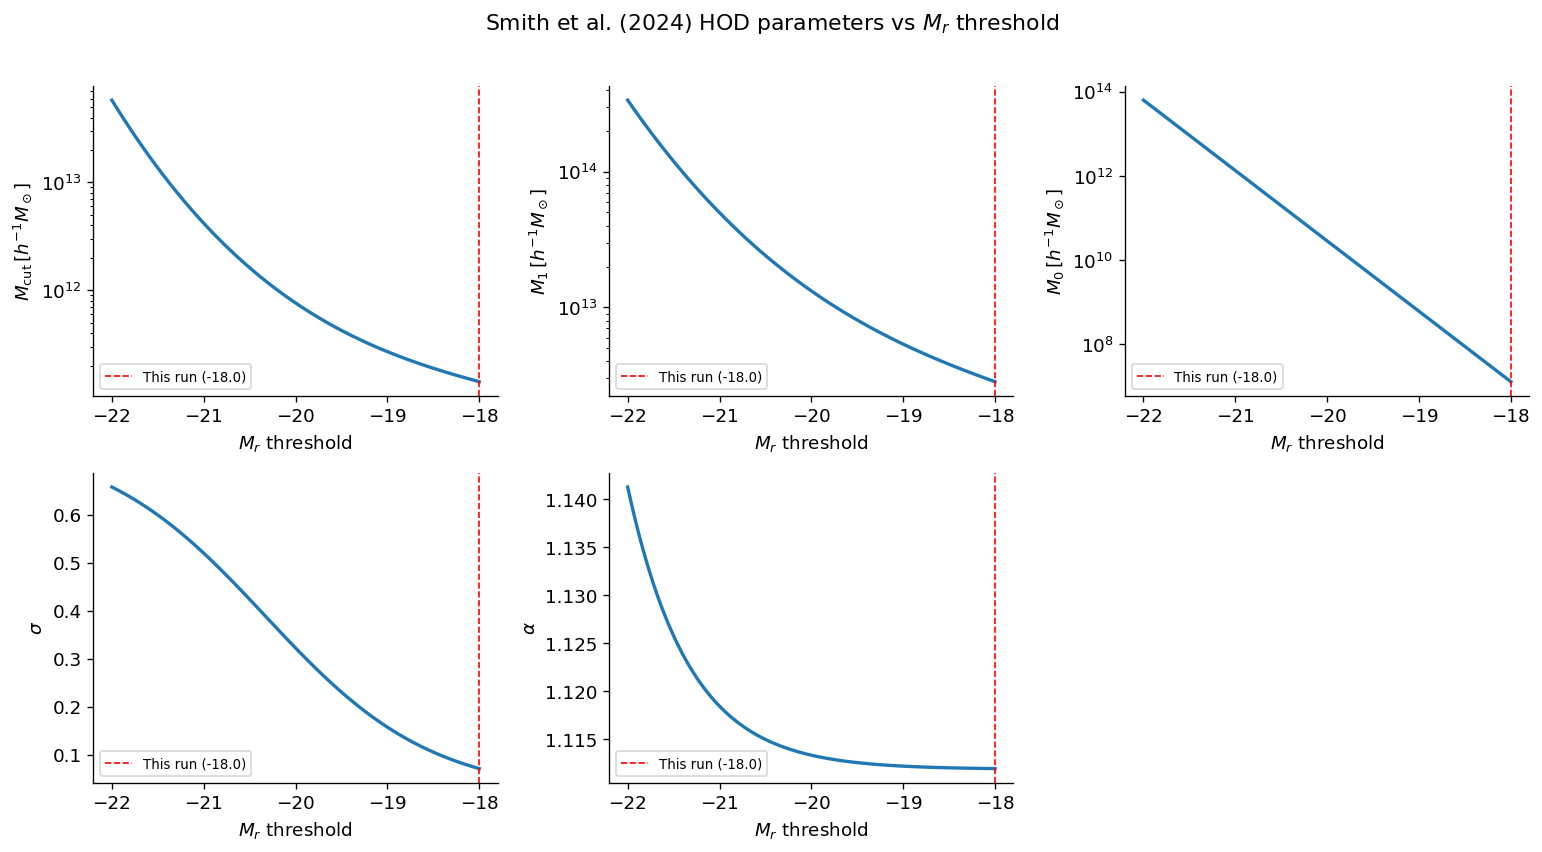

Baseline HOD at Mr = -18.0:
  Mcut    : 1.425688e+11
  M1      : 2.838134e+12
  M0      : 1.276397e+07
  sigma   : 7.105636e-02
  alpha   : 1.111940e+00
  kappa   : 8.952849e-05



In [3]:

# 17 fitted coefficients — Smith et al. (2024) Table 1, AbacusSummit c000/ph000
# Verbatim from HODFits_BGS.__init__
_A_min, _B_min, _C_min, _D_min = -0.1163295942035853792, -0.5759066407274642252,  0.1437085418067726994, -0.01908335449679073731
_A_sig, _B_sig, _C_sig, _D_sig =  0.01832666435246161490,  0.7584865035087475782,  1.103103765754579246,   0.3277787214124110449
_A_0,   _B_0                   = -0.5468895455660652827,  -1.673562380257160864
_A_1,   _B_1,   _C_1,   _D_1  =  1.121497360473139082,  -0.4725625165007949491,  0.09200038944813740405, -0.01141762462160326314
_A_al,  _B_al,  _C_al          =  1.111866664500087198,   4.473949866395862784,  -4.353309870091147893


def _M_function(Mr, A, B, C, D):
    """Cubic polynomial in x = Mr + 20.  Returns log10(mass)."""
    x = Mr + 20
    return (A + 12) + B*x + C*x**2 + D*x**3


def _M0_function(Mr, A, B):
    """Linear in x = Mr + 20.  Returns log10(M0)."""
    x = Mr + 20
    return (A + 11) + B*x


def _sigma_function(Mr, A, B, C, D):
    """Sigmoid in x = Mr + 20.  Returns sigma (dimensionless)."""
    x = Mr + 20
    return A + (B - A) / (1.0 + np.exp(C * (x + D)))


def _alpha_function(Mr, A, B, C):
    """Power-law in x = Mr + 20.  Returns alpha (dimensionless)."""
    x = Mr + 20
    return A + B**(-x + C)


def get_hod_params(Mr):
    """
    Return Smith et al. (2024) DESI BGS HOD parameters for luminosity
    threshold Mr (scalar or array).

    Parameters
    ----------
    Mr : float or array-like
        r-band absolute magnitude threshold (e.g. -20.0).
        Valid calibration range: -22 ≤ Mr ≤ -18.

    Returns
    -------
    dict with keys: Mcut, M1, M0, sigma, alpha, kappa
        Masses in h⁻¹ M☉.  sigma, alpha, kappa dimensionless.
    """
    Mcut  = 10**_M_function(Mr, _A_min, _B_min, _C_min, _D_min)
    M1    = 10**_M_function(Mr, _A_1,   _B_1,   _C_1,   _D_1  )
    M0    = 10**_M0_function(Mr, _A_0,  _B_0)
    sigma = _sigma_function(Mr, _A_sig, _B_sig, _C_sig, _D_sig)
    alpha = _alpha_function(Mr, _A_al,  _B_al,  _C_al)
    kappa = M0 / Mcut
    return dict(Mcut=Mcut, M1=M1, M0=M0, sigma=sigma, alpha=alpha, kappa=kappa)


# 1. Point check at Mr = -20.5
#    Expected values from run_pipeline.py L1687-1692 (reference run)
ref_Mr     = -20.5
ref_params = get_hod_params(ref_Mr)
expected   = dict(Mcut=1.62e12, M1=2.41e13, M0=1.95e11, sigma=0.42, alpha=1.11)

print(f"HOD parameters at Mr = {ref_Mr}:")
print(f"  {'param':<8}  {'computed':>12}  {'reference':>12}  {'match?':>8}")
print(f"  {'-'*46}")
all_ok = True
for k, exp_v in expected.items():
    got_v = ref_params[k]
    ok    = np.isclose(got_v, exp_v, rtol=0.02)
    all_ok &= ok
    print(f"  {k:<8}  {got_v:>12.4e}  {exp_v:>12.4e}  {'✓' if ok else '✗'}")

assert all_ok, "HOD parameter mismatch > 2% — check coefficients."
print()

# 2. Calibration range visualisation
Mr_range = np.linspace(-18, -22, 100)
p        = get_hod_params(Mr_range)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()
params_to_plot = [
    ('Mcut',  r'$M_{\rm cut}\,[h^{-1}M_\odot]$', True),
    ('M1',    r'$M_1\,[h^{-1}M_\odot]$',          True),
    ('M0',    r'$M_0\,[h^{-1}M_\odot]$',          True),
    ('sigma', r'$\sigma$',                          False),
    ('alpha', r'$\alpha$',                          False),
    ('kappa', r'$\kappa$',                          False),
]
for ax, (key, ylabel, logy) in zip(axes, params_to_plot):
    ax.plot(Mr_range, p[key], lw=2)
    ax.set_xlabel(r'$M_r$ threshold')
    ax.set_ylabel(ylabel)
    ax.axvline(MR_THRESH, color='red', ls='--', lw=1, label=f'This run ({MR_THRESH})')
    if logy:
        ax.set_yscale('log')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Smith et al. (2024) HOD parameters vs $M_r$ threshold', y=1.01)
plt.tight_layout()
plt.show()

# 3. Baseline HOD for this run
BASE_HOD = get_hod_params(MR_THRESH)
print(f"Baseline HOD at Mr = {MR_THRESH}:")
for k, v in BASE_HOD.items():
    print(f"  {k:<8}: {v:.6e}")
print()


F_spline endpoint + linearisation checks:
  ✓ F_spline(−100)==−1, F_spline(0)==0, F_spline(+100)==+1
  ✓ Max relative deviation from erf near x=0: 3.52% (< 5%)
  ✓ fcen_thresh() monotonically non-decreasing with log10(M)
  ✓ 0 ≤ ⟨Ncen⟩ ≤ 1  (range: [0.0001, 1.0000])
  ✓ ⟨Nsat⟩ ≥ 0 everywhere  (max: 679.32)



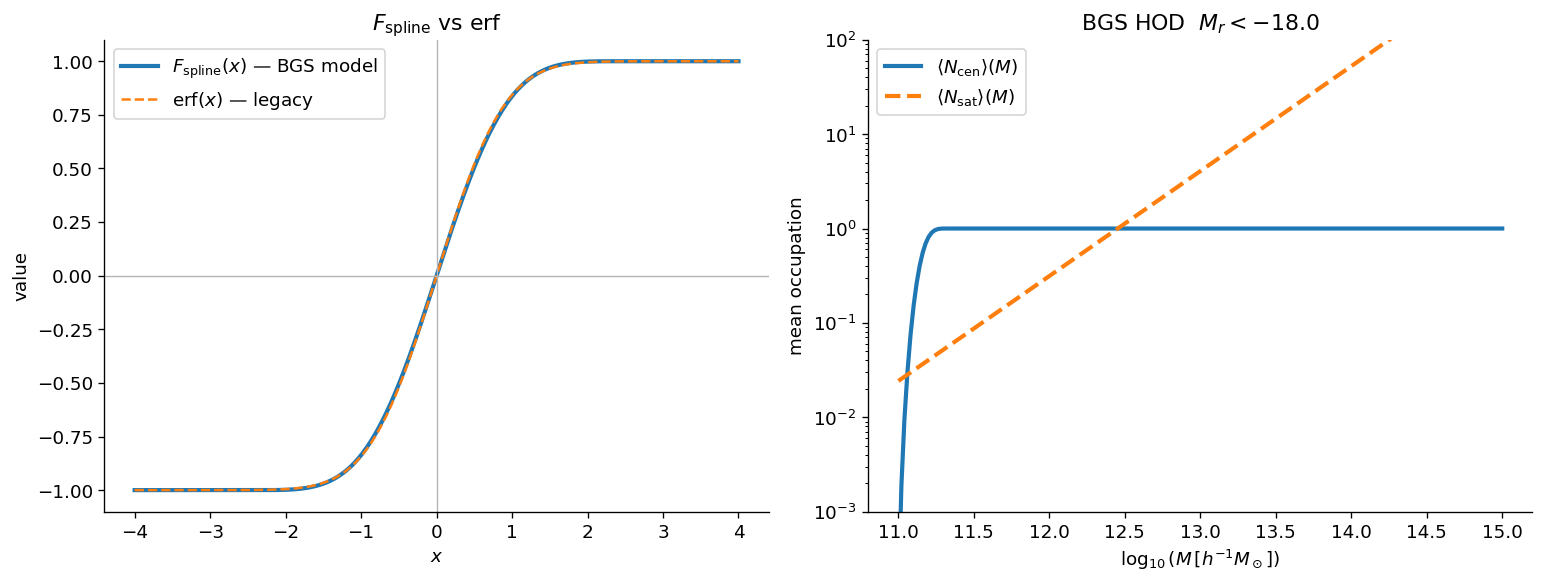

In [4]:
def F_spline(x):
    """
    Analytic CDF of the spline kernel — Smith et al. (2024) arXiv:2312.08792v2.

    Replaces erf() in the BGS central occupation:
        ⟨Ncen⟩(M) = 0.5 * (1 + F_spline(x))
        x = (log10 M − log10 Mcut) / sigma

    Piecewise in t = x / sqrt(6):
        |t| ≤ 0.5 : cubic piece  (inner region)
        |t| ≤ 1.0 : quartic piece (outer region)
        |t| >  1  : ±1  (saturated — compact support)

    Near x=0: F_spline ≈ erf to first order (both ≈ x/√π).
    At x=±∞ : F_spline = ±1 exactly (finite transition width).

    Parameters
    ----------
    x : float or array-like

    Returns
    -------
    float or ndarray in [-1, +1]
    """
    x  = np.asarray(x, dtype=float)
    t  = x / np.sqrt(6)
    at = np.abs(t)

    piece1 = np.sign(t) * ((8/3)*at - (16/3)*at**3 + 4*at**4)
    piece2 = np.sign(t) * (1 - (4/3)*(1 - at)**4)
    piece3 = np.sign(t) * 1.0

    return np.where(at <= 0.5, piece1,
           np.where(at <= 1.0, piece2, piece3))


def fcen_thresh(lgm, hod_params):
    """
    BGS central occupation: cumulative probability P(Lcen > L | M).

    ⟨Ncen⟩(M) = 0.5 * (1 + F_spline(x))
    x = (log10 M − log10 Mcut) / sigma

    Parameters
    ----------
    lgm        : float or array  log10(halo mass in h⁻¹ M☉)
    hod_params : dict            output of get_hod_params(Mr)
                                 (scalar or array — must broadcast with lgm)

    Returns
    -------
    float or ndarray  in [0, 1]
    """
    x = (np.asarray(lgm) - np.log10(hod_params['Mcut'])) / hod_params['sigma']
    return 0.5 * (1.0 + F_spline(x))


def Nsat_thresh(lgm, hod_params):
    """
    Mean satellite count ⟨Nsat⟩(M > L_thresh).

    ⟨Nsat⟩(M) = ((M − M0) / M1)^alpha   for M > M0
                0                          otherwise

    Note: the ncen-gating factor is applied in generate_mock(), not here,
    so this function returns the *unconditional* satellite mean.
    LuminosityAssigner normalises by Nsat_thresh(Mr_max) — the ratio
    cancels the ncen factor correctly.

    Parameters
    ----------
    lgm        : float or array  log10(halo mass in h⁻¹ M☉)
    hod_params : dict            output of get_hod_params(Mr)

    Returns
    -------
    float or ndarray  ≥ 0
    """
    mhalo = 10**np.asarray(lgm, dtype=float)
    Dm    = (mhalo - hod_params['M0']) / hod_params['M1']
    Dm    = np.where(Dm < 0.0, 0.0, Dm)
    return Dm ** hod_params['alpha']

print("F_spline endpoint + linearisation checks:")

# (a) Endpoint saturation
assert np.isclose(F_spline(-100.0), -1.0), "F_spline(-100) ≠ -1"
assert np.isclose(F_spline(  0.0),   0.0), "F_spline(0) ≠ 0"
assert np.isclose(F_spline( 100.0), +1.0), "F_spline(100) ≠ +1"
print("  ✓ F_spline(−100)==−1, F_spline(0)==0, F_spline(+100)==+1")

# (b) First-order agreement with erf near x=0  (both ≈ x/√π)
from scipy.special import erf
x_small = np.linspace(-0.1, 0.1, 21)
rel_err  = np.max(np.abs(F_spline(x_small) - erf(x_small)) / (np.abs(erf(x_small)) + 1e-12))
assert rel_err < 0.05, f"F_spline deviates from erf by {rel_err:.2%} near x=0"
print(f"  ✓ Max relative deviation from erf near x=0: {rel_err:.2%} (< 5%)")

# (c) fcen_thresh is monotonically non-decreasing with halo mass
lgm_test  = np.linspace(11.0, 15.0, 200)
p_test    = get_hod_params(MR_THRESH)
fcen_test = fcen_thresh(lgm_test, p_test)
assert np.all(np.diff(fcen_test) >= -1e-12), "fcen_thresh is not monotone with mass!"
print("  ✓ fcen_thresh() monotonically non-decreasing with log10(M)")

# (d) 0 ≤ ⟨Ncen⟩ ≤ 1 across the full halo mass range
assert np.all(fcen_test >= 0.0),  "⟨Ncen⟩ < 0 detected"
assert np.all(fcen_test <= 1.0),  "⟨Ncen⟩ > 1 detected"
print(f"  ✓ 0 ≤ ⟨Ncen⟩ ≤ 1  (range: [{fcen_test.min():.4f}, {fcen_test.max():.4f}])")

# (e) ⟨Nsat⟩ ≥ 0 everywhere (zero-floor enforced)
nsat_test = Nsat_thresh(lgm_test, p_test)
assert np.all(nsat_test >= 0.0),  "⟨Nsat⟩ < 0 detected — zero-floor failed"
print(f"  ✓ ⟨Nsat⟩ ≥ 0 everywhere  (max: {nsat_test.max():.2f})")

print()

# Visualisation — compare F_spline vs erf, and plot occupation curves
x_vis    = np.linspace(-4, 4, 300)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: F_spline vs erf
ax = axes[0]
ax.plot(x_vis, F_spline(x_vis), lw=2.5, label='$F_{\\rm spline}(x)$ — BGS model')
ax.plot(x_vis, erf(x_vis),      lw=1.5, ls='--', label='$\\mathrm{erf}(x)$ — legacy')
ax.axhline(0,  color='0.7', lw=0.8)
ax.axvline(0,  color='0.7', lw=0.8)
ax.set_xlabel('$x$'); ax.set_ylabel('value')
ax.set_title('$F_{\\rm spline}$ vs $\\mathrm{erf}$')
ax.legend()

# Right: ⟨Ncen⟩ and ⟨Nsat⟩ vs halo mass
ax = axes[1]
ax.plot(lgm_test, fcen_test,  lw=2.5, label=r'$\langle N_{\rm cen}\rangle(M)$')
ax.plot(lgm_test, nsat_test,  lw=2.5, ls='--', label=r'$\langle N_{\rm sat}\rangle(M)$')
ax.set_yscale('log'); ax.set_ylim(1e-3, 1e2)
ax.set_xlabel(r'$\log_{10}(M\,[h^{-1}M_\odot])$')
ax.set_ylabel('mean occupation')
ax.set_title(f'BGS HOD  $M_r < {MR_THRESH}$')
ax.legend()

plt.tight_layout()
plt.show()



In [5]:

# Physical constants (verbatim from Mocker.__init__ in Gen_Cat_Fits.ipynb)
RHOC = 2.7754e11   # (Msun/h) / (Mpc/h)^3 — critical density at z=0
DVIR = 200.0 * OMEGA_M   # virial density threshold


def EHub(z, Om=None):
    """
    Dimensionless Hubble parameter E(z) = H(z)/H0  for flat ΛCDM.

    Parameters
    ----------
    z  : float   redshift
    Om : float   Omega_matter (defaults to OMEGA_M from Chapter 3)
    """
    if Om is None:
        Om = OMEGA_M
    return np.sqrt(Om * (1 + z)**3 + (1 - Om))


def compute_rvir_con(mass, rs_kpc, z=None):
    """
    Compute virial radius and NFW concentration for each halo.

    The virial radius is defined via the M200b density threshold:
        M = (4π/3) · Δ_vir · ρ_c(z) · R_vir³
    where Δ_vir = 200 × Ω_m (background density convention).

    Parameters
    ----------
    mass   : ndarray  m200b [h⁻¹ M☉]
    rs_kpc : ndarray  NFW scale radius [comoving kpc/h]  ('rs' column)
    z      : float    redshift (defaults to REDSHIFT from Chapter 3)

    Returns
    -------
    rvir : ndarray  [comoving Mpc/h]
    con  : ndarray  concentration c = Rvir / rs  [dimensionless]
    """
    if z is None:
        z = REDSHIFT
    rhoc_z    = RHOC * EHub(z)**2
    rvir_phys = (3.0 * mass / (4.0 * np.pi * DVIR * rhoc_z))**(1.0/3.0)
    rvir_com  = rvir_phys * (1.0 + z)   # physical → comoving
    rs_com    = rs_kpc * 1e-3            # kpc/h → Mpc/h
    con       = rvir_com / rs_com
    return rvir_com, con


# ---- Validate on the full halo array ----
rvir_all, con_all = compute_rvir_con(halos[MASSDEF], halos['rs'])

assert np.all(rvir_all > 0), 'negative rvir detected'
assert np.all(con_all  > 0), 'negative concentration detected'

n_highc   = np.sum(con_all > 100)
frac_highc = n_highc / con_all.size
# A small fraction of low-mass halos with tiny rs is physically expected
assert frac_highc < 0.05, f'Too many high-c halos ({100*frac_highc:.1f}%)'

print('Halo rvir / concentration:')
print(f'  rvir  : {rvir_all.min():.4f} – {rvir_all.max():.4f}  Mpc/h')
print(f'  con   : {con_all.min():.2f} – {con_all.max():.2f}  (dimensionless)')
print(f'  c>100 : {n_highc:,}  ({100*frac_highc:.2f}%  of catalogue)  — expected')
print(f'  median c : {np.median(con_all):.2f}')
print('✓ compute_rvir_con validated.')


Halo rvir / concentration:
  rvir  : 0.1161 – 2.2969  Mpc/h
  con   : 1.27 – 326.80  (dimensionless)
  c>100 : 268  (0.08%  of catalogue)  — expected
  median c : 13.75
✓ compute_rvir_con validated.


In [6]:
def Mencl_nfw(x):
    """
    NFW enclosed mass (dimensionless):  M(<r) / M_total = [ln(1+x) - x/(1+x)] / [ln(1+c) - c/(1+c)]

    Here we return the unnormalised numerator; the caller divides by Mencl_nfw(c).
    x = r / r_s
    """
    return np.log(1.0 + x) - x / (1.0 + x)


def gen_rsamp(Nsat, cvir, Rvir, rng):
    """
    Sample Nsat radial distances [Mpc/h] from the NFW CDF via
    inverse-transform sampling on a fine grid.

    The grid extends to 2*cvir (in units of r_s) to capture the
    outer NFW profile used for satellite placement.

    Parameters
    ----------
    Nsat : int
    cvir : float   NFW concentration c = Rvir / rs
    Rvir : float   virial radius [Mpc/h]
    rng  : np.random.RandomState

    Returns
    -------
    rsamp : ndarray (Nsat,)  radial distances [Mpc/h]
    """
    xmax  = 2.0 * cvir
    xfine = np.linspace(0.0, xmax, 100_000)
    Px    = Mencl_nfw(xfine)

    # Taylor series near x=0 for numerical stability (avoids 0/0)
    ind_small = xfine < 1e-3
    if ind_small.any():
        xs = xfine[ind_small]
        Px[ind_small] = (xs**2/2.0 - 2*xs**3/3.0
                         + 3*xs**4/4.0 - 4*xs**5/5.0)

    Px   /= Mencl_nfw(cvir)          # normalise to [0, 1]
    rs    = Rvir / cvir              # scale radius [Mpc/h]
    rsamp = np.interp(rng.rand(Nsat), Px, xfine) * rs
    return rsamp


def gen_NFW_profile(Nsat, cvir, Rvir, rng):
    """
    Generate Nsat 3-d satellite offsets [Mpc/h] from halo centre,
    distributed isotropically following the NFW profile.

    Parameters
    ----------
    Nsat : int
    cvir : float   NFW concentration
    Rvir : float   virial radius [Mpc/h]
    rng  : np.random.RandomState

    Returns
    -------
    offsets : ndarray (Nsat, 3)  [Mpc/h]
    """
    phi       = 2.0 * np.pi * rng.rand(Nsat)
    cos_theta = 2.0 * rng.rand(Nsat) - 1.0
    sin_theta = np.sqrt(np.maximum(0.0, 1.0 - cos_theta**2))
    r         = gen_rsamp(Nsat, cvir, Rvir, rng)

    dx = r * sin_theta * np.sin(phi)
    dy = r * sin_theta * np.cos(phi)
    dz = r * cos_theta
    return np.column_stack([dx, dy, dz])


# ---- Validation ----
_rng_test = np.random.RandomState(0)
_pos_test  = gen_NFW_profile(1000, cvir=10.0, Rvir=1.0, rng=_rng_test)
_r_test    = np.sqrt((_pos_test**2).sum(axis=1))

assert _pos_test.shape == (1000, 3),  'shape mismatch'
assert np.all(_r_test > 0),           'zero-radius satellite'
assert np.all(_r_test < 2.0),         'satellite beyond 2*Rvir'
print(f'NFW sampler test  (cvir=10, Rvir=1 Mpc/h):')
print(f'  r range : {_r_test.min():.4f} – {_r_test.max():.4f}  Mpc/h')
print(f'  median r : {np.median(_r_test):.4f}  Mpc/h')
print('✓ gen_NFW_profile validated.')


NFW sampler test  (cvir=10, Rvir=1 Mpc/h):
  r range : 0.0015 – 0.9999  Mpc/h
  median r : 0.3611  Mpc/h
✓ gen_NFW_profile validated.


In [7]:
def draw_centrals(lgm, hod_params, rng):
    """
    Draw central galaxy boolean flags via Bernoulli sampling.

    Uses the BGS F_spline occupation via fcen_thresh() from Chapter 5.

    Parameters
    ----------
    lgm        : ndarray (N_halos,)  log10(halo mass)
    hod_params : dict                output of get_hod_params(Mr)
    rng        : np.random.RandomState

    Returns
    -------
    ncen     : bool ndarray (N_halos,)   True = halo has a central galaxy
    mean_cen : float ndarray (N_halos,)  ⟨Ncen⟩(M) — the occupation probability
    """
    mean_cen = fcen_thresh(lgm, hod_params)          # BGS: F_spline, NOT erf
    u        = rng.rand(lgm.size)
    ncen     = mean_cen >= u                          # Bernoulli draw
    return ncen, mean_cen


def draw_satellites(lgm, hod_params, rng, ncen):
    """
    Draw satellite galaxy counts via ncen-gated Poisson sampling.

    The Poisson mean is:
        λ(M) = Ncen(M) · Nsat_thresh(M)

    This matches simulator.py L170-171 for the BGS/erf branches.

    Parameters
    ----------
    lgm        : ndarray (N_halos,)  log10(halo mass)
    hod_params : dict
    rng        : np.random.RandomState
    ncen       : bool ndarray (N_halos,)  from draw_centrals()

    Returns
    -------
    nsat     : int ndarray (N_halos,)
    mean_sat : float ndarray (N_halos,)  λ(M) before Poisson draw
    """
    mean_sat_raw = Nsat_thresh(lgm, hod_params)   # unconditional mean
    mean_sat     = ncen.astype(float) * mean_sat_raw   # ncen gate
    nsat         = rng.poisson(mean_sat)           # Poisson sample
    return nsat, mean_sat


# ---- Occupation sanity check at baseline HOD ----
_rng_chk = np.random.RandomState(SEED)
_lgm_all = np.log10(halos[MASSDEF])
_ncen_chk, _mean_cen = draw_centrals(_lgm_all, BASE_HOD, _rng_chk)
_nsat_chk, _mean_sat = draw_satellites(_lgm_all, BASE_HOD, _rng_chk, _ncen_chk)

_ntot = _ncen_chk.sum() + _nsat_chk.sum()
_fsat = _nsat_chk.sum() / _ntot if _ntot > 0 else 0

assert np.all((_mean_cen >= 0) & (_mean_cen <= 1)), '⟨Ncen⟩ out of [0,1]'
assert np.all(_mean_sat >= 0),                       '⟨Nsat⟩ < 0'
assert np.all(_nsat_chk >= 0),                       'negative satellite count'
print(f'draw_centrals + draw_satellites check (seed={SEED}):')
print(f'  Centrals   : {_ncen_chk.sum():>8,}')
print(f'  Satellites : {_nsat_chk.sum():>8,}')
print(f'  Total      : {_ntot:>8,}')
print(f'  f_sat      : {_fsat:.4f}  (expect ~0.18–0.25 for Mr<-20)')
print('✓ draw_centrals / draw_satellites validated.')


draw_centrals + draw_satellites check (seed=10):
  Centrals   :  207,998
  Satellites :  102,687
  Total      :  310,685
  f_sat      : 0.3305  (expect ~0.18–0.25 for Mr<-20)
✓ draw_centrals / draw_satellites validated.


In [8]:
def generate_mock(halos, params, seed=SEED, lbox=None, massdef=MASSDEF,
                  verbose=True):
    """
    Generate a threshold mock galaxy catalogue.

    Design: one RandomState, created fresh from `seed`, is passed
    sequentially into draw_centrals → draw_satellites → gen_NFW_profile.
    Changing `params` changes HOD-driven selection but keeps the
    underlying random draws in the same stream — this is the
    seed-matching strategy for finite-difference derivatives.

    Parameters
    ----------
    halos   : structured ndarray   Sahyadri halo catalogue from Chapter 3
    params  : dict                 HOD parameters (output of get_hod_params)
    seed    : int                  RNG seed (default = global SEED)
    lbox    : float                box size [Mpc/h] (default = LBOX)
    massdef : str                  halo mass column (default = MASSDEF)
    verbose : bool

    Returns
    -------
    dict with keys:
        x, y, z       : float arrays, galaxy positions [Mpc/h], periodic
        is_central    : bool array   True = central galaxy
        halo_idx      : int array    index into halos for each galaxy
        ncen_total    : int
        nsat_total    : int
    """
    if lbox is None:
        lbox = LBOX

    rng = np.random.RandomState(seed=seed)

    # Pre-compute halo properties (shared for all draws)
    lgm       = np.log10(halos[massdef])
    rvir, con = compute_rvir_con(halos[massdef], halos['rs'])

    # ── Step 1: central occupation (BGS spline via draw_centrals) ──
    ncen, _ = draw_centrals(lgm, params, rng)

    # ── Step 2: satellite counts (Poisson, ncen-gated) ──────────────
    nsat, _ = draw_satellites(lgm, params, rng, ncen)

    # ── Step 3: central positions = halo centres ─────────────────────
    idx_cen = np.where(ncen)[0]
    cen_x   = halos['x'][idx_cen].copy()
    cen_y   = halos['y'][idx_cen].copy()
    cen_z   = halos['z'][idx_cen].copy()

    # ── Step 4: satellite positions from NFW profile ─────────────────
    nsat_total = int(nsat.sum())
    sat_x      = np.empty(nsat_total)
    sat_y      = np.empty(nsat_total)
    sat_z      = np.empty(nsat_total)
    sat_hidx   = np.empty(nsat_total, dtype=int)

    ptr    = 0
    indsel = np.where(nsat > 0)[0]   # only halos that have satellites
    for i in indsel:
        ns  = int(nsat[i])
        pos = gen_NFW_profile(ns, con[i], rvir[i], rng)
        sat_x[ptr:ptr+ns]    = (pos[:, 0] + halos['x'][i]) % lbox
        sat_y[ptr:ptr+ns]    = (pos[:, 1] + halos['y'][i]) % lbox
        sat_z[ptr:ptr+ns]    = (pos[:, 2] + halos['z'][i]) % lbox
        sat_hidx[ptr:ptr+ns] = i
        ptr += ns

    # ── Step 5: stack centrals + satellites ──────────────────────────
    all_x = np.concatenate([cen_x, sat_x])
    all_y = np.concatenate([cen_y, sat_y])
    all_z = np.concatenate([cen_z, sat_z])

    ncen_total = idx_cen.size
    is_central = np.zeros(ncen_total + nsat_total, dtype=bool)
    is_central[:ncen_total] = True
    halo_idx_all = np.concatenate([idx_cen, sat_hidx])

    if verbose:
        ntot = ncen_total + nsat_total
        fsat = nsat_total / ntot if ntot > 0 else 0
        print(f'Mock generated  (seed={seed}):')
        print(f'  Centrals  : {ncen_total:>8,}')
        print(f'  Satellites: {nsat_total:>8,}')
        print(f'  Total     : {ntot:>8,}')
        print(f'  f_sat     : {fsat:.4f}')

    return {
        'x':          all_x,
        'y':          all_y,
        'z':          all_z,
        'is_central': is_central,
        'halo_idx':   halo_idx_all,
        'ncen_total': ncen_total,
        'nsat_total': nsat_total,
    }


# ── Generate the baseline mock ───────────────────────────────
print('Generating baseline mock...')
mock_base = generate_mock(halos, BASE_HOD, seed=SEED)

# ── Hard validation ──────────────────────────────────────────
ntot = mock_base['ncen_total'] + mock_base['nsat_total']
fsat = mock_base['nsat_total'] / ntot

# All positions inside the box
for coord in ['x', 'y', 'z']:
    assert mock_base[coord].min() >= 0.0, f'{coord} < 0'
    assert mock_base[coord].max() < LBOX,  f'{coord} >= LBOX'

# is_central flag counts must match ncen_total / nsat_total
assert mock_base['is_central'].sum()  == mock_base['ncen_total'], 'is_central count mismatch'
assert (~mock_base['is_central']).sum() == mock_base['nsat_total'], 'is_satellite count mismatch'

# Physically plausible satellite fraction for Mr < -20
assert 0.10 < fsat < 0.40, f'f_sat={fsat:.3f} outside expected range [0.10, 0.40]'

print()
print('Validation:')
print(f'  positions in [0, {LBOX})   : ✓')
print(f'  is_central flag consistent : ✓')
print(f'  f_sat = {fsat:.4f}  (expect 0.10–0.40 for Mr<{MR_THRESH}) : ✓')
print()
print('✓ Chapter 6 complete — generate_mock() (BGS F_spline) validated.')


Generating baseline mock...
Mock generated  (seed=10):
  Centrals  :  207,998
  Satellites:  102,687
  Total     :  310,685
  f_sat     : 0.3305

Validation:
  positions in [0, 200.0)   : ✓
  is_central flag consistent : ✓
  f_sat = 0.3305  (expect 0.10–0.40 for Mr<-18.0) : ✓

✓ Chapter 6 complete — generate_mock() (BGS F_spline) validated.


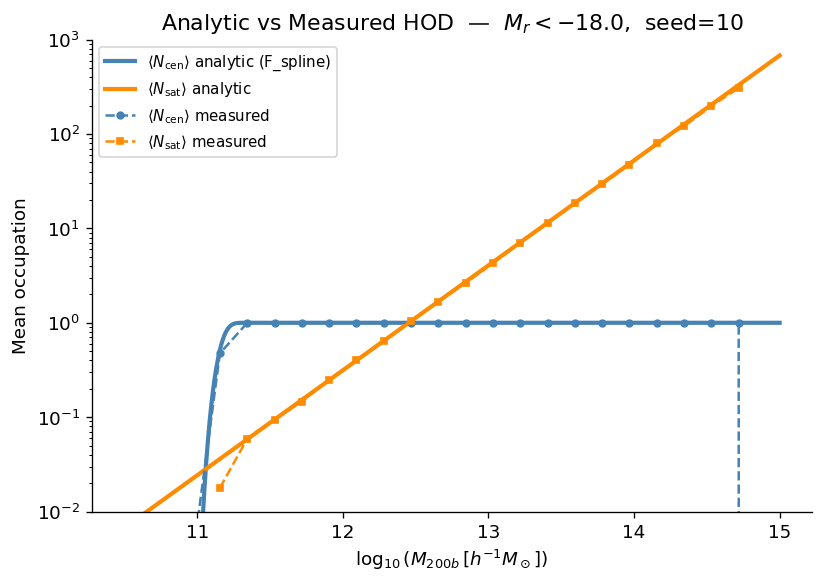

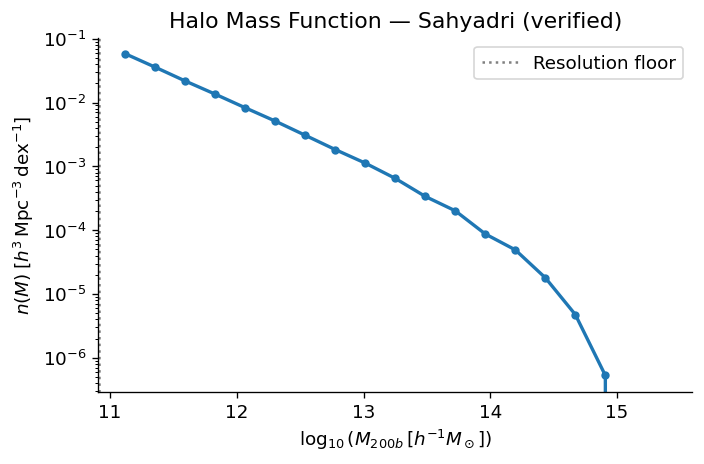

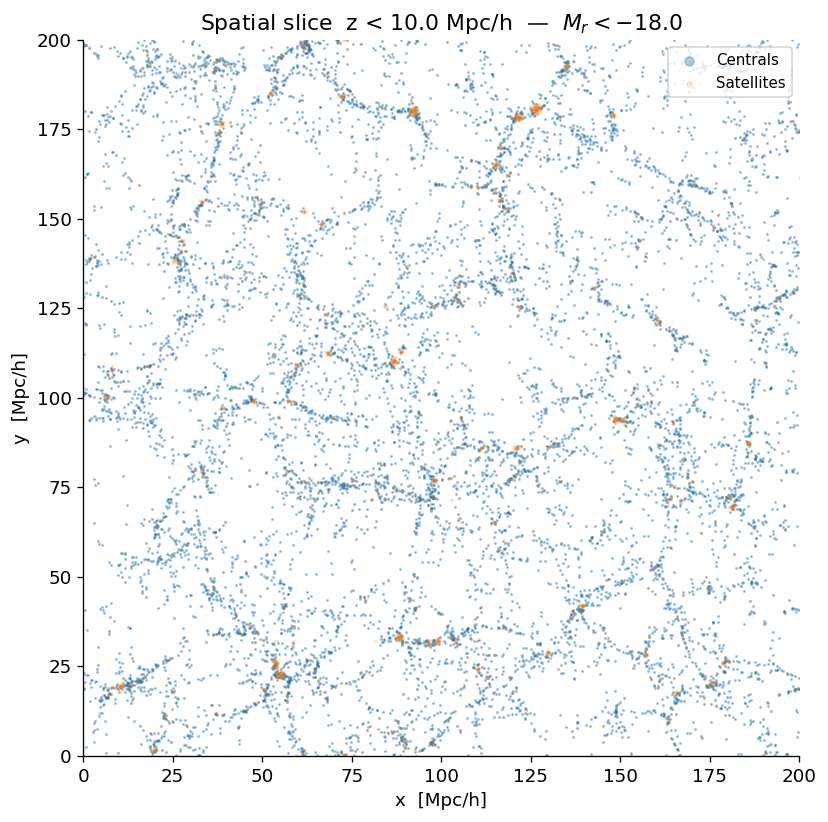

Max |⟨Ncen⟩_meas − ⟨Ncen⟩_analytic| = 0.0423  (< 0.10) ✓

✓ Chapter 7 complete — baseline mock statistics validated.


In [9]:
lgm_all  = np.log10(halos[MASSDEF])
lgm_bins = np.linspace(10.5, 15.0, 25)
lgm_cen  = 0.5 * (lgm_bins[1:] + lgm_bins[:-1])

# ── Reconstruct per-halo occupation from mock_base ───────────
cen_halo_idx  = mock_base['halo_idx'][ mock_base['is_central']]
sat_halo_idx  = mock_base['halo_idx'][~mock_base['is_central']]

ncen_mask   = np.zeros(halos.size, dtype=bool)
nsat_counts = np.zeros(halos.size, dtype=int)
ncen_mask[cen_halo_idx] = True
np.add.at(nsat_counts, sat_halo_idx, 1)

# Binned mean occupation
ncen_meas = np.zeros(len(lgm_cen))
nsat_meas = np.zeros(len(lgm_cen))
for b in range(len(lgm_cen)):
    mask = (lgm_all >= lgm_bins[b]) & (lgm_all < lgm_bins[b+1])
    if mask.sum() > 0:
        ncen_meas[b] = ncen_mask[mask].mean()
        nsat_meas[b] = nsat_counts[mask].mean()

# Analytic curves from canonical functions
lgm_fine      = np.linspace(10.5, 15.0, 400)
ncen_analytic = fcen_thresh(lgm_fine, BASE_HOD)
nsat_analytic = Nsat_thresh(lgm_fine, BASE_HOD)

# ── Figure 1: analytic vs measured HOD ───────────────────────
fig1, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(lgm_fine, ncen_analytic, color='steelblue', lw=2.5,
         label=r'$\langle N_{\rm cen}\rangle$ analytic (F_spline)')
ax1.plot(lgm_fine, np.where(nsat_analytic > 1e-4, nsat_analytic, np.nan),
         color='darkorange', lw=2.5,
         label=r'$\langle N_{\rm sat}\rangle$ analytic')
ax1.plot(lgm_cen, ncen_meas, 'o--', ms=4, color='steelblue',
         label=r'$\langle N_{\rm cen}\rangle$ measured')
ax1.plot(lgm_cen, np.where(nsat_meas > 1e-4, nsat_meas, np.nan),
         's--', ms=4, color='darkorange',
         label=r'$\langle N_{\rm sat}\rangle$ measured')
ax1.set_yscale('log'); ax1.set_ylim(1e-2, 1e3)
ax1.set_xlabel(r'$\log_{10}(M_{200b}\,[h^{-1}M_\odot])$')
ax1.set_ylabel('Mean occupation')
ax1.set_title(f'Analytic vs Measured HOD  —  $M_r < {MR_THRESH}$,  seed={SEED}')
ax1.legend(fontsize=9)
plt.tight_layout(); plt.show()

# ── Figure 2: HMF ────────────────────────────────────────────
hmf_bins  = np.linspace(11.0, 15.5, 20)
hmf_cnt, _ = np.histogram(lgm_all, bins=hmf_bins)
hmf_mid    = 0.5 * (hmf_bins[1:] + hmf_bins[:-1])
hmf_n      = hmf_cnt / (LBOX**3 * (hmf_bins[1] - hmf_bins[0]))

fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(hmf_mid, hmf_n, 'o-', lw=2, ms=4)
ax2.axvline(np.log10(halos[MASSDEF].min()), color='0.5', ls=':',
            label=f'Resolution floor')
ax2.set_yscale('log')
ax2.set_xlabel(r'$\log_{10}(M_{200b}\,[h^{-1}M_\odot])$')
ax2.set_ylabel(r'$n(M)\;[h^3\,{\rm Mpc}^{-3}\,{\rm dex}^{-1}]$')
ax2.set_title('Halo Mass Function — Sahyadri (verified)')
ax2.legend(); plt.tight_layout(); plt.show()

# ── Figure 3: spatial slice ───────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(7, 7))
slice_depth = 10.0
thin = mock_base['z'] < slice_depth
ax3.scatter(mock_base['x'][thin &  mock_base['is_central']],
            mock_base['y'][thin &  mock_base['is_central']],
            s=0.8, c='#1f77b4', alpha=0.35, label='Centrals')
ax3.scatter(mock_base['x'][thin & ~mock_base['is_central']],
            mock_base['y'][thin & ~mock_base['is_central']],
            s=0.3, c='#ff7f0e', alpha=0.15, label='Satellites')
ax3.set_xlim(0, LBOX); ax3.set_ylim(0, LBOX); ax3.set_aspect('equal')
ax3.set_xlabel('x  [Mpc/h]'); ax3.set_ylabel('y  [Mpc/h]')
ax3.set_title(f'Spatial slice  z < {slice_depth} Mpc/h  —  $M_r < {MR_THRESH}$')
ax3.legend(markerscale=6, fontsize=9, loc='upper right')
plt.tight_layout(); plt.show()

# ── Validation: measured occupation vs analytic ───────────────
# Only check bins with enough halos (>20) to avoid shot-noise failures
good = np.array([(((lgm_all >= lgm_bins[b]) & (lgm_all < lgm_bins[b+1])).sum() > 20)
                  for b in range(len(lgm_cen))])

# ⟨Ncen⟩: measured should be within 10 percentage points of analytic
ncen_analytic_binned = fcen_thresh(lgm_cen, BASE_HOD)
max_cen_dev = np.max(np.abs(ncen_meas[good] - ncen_analytic_binned[good]))
assert max_cen_dev < 0.10, f'⟨Ncen⟩ deviates by {max_cen_dev:.3f} — check HOD'

print(f'Max |⟨Ncen⟩_meas − ⟨Ncen⟩_analytic| = {max_cen_dev:.4f}  (< 0.10) ✓')
print()
print('✓ Chapter 7 complete — baseline mock statistics validated.')


Computing baseline wp(rp)...
  N_RP = 50  rp in [0.521, 28.837] Mpc/h
  wp   in [1.09, 113.25] Mpc/h

 bin    rp [Mpc/h]    wp [Mpc/h]
----------------------------------
   0        0.5215      113.2493
   1        0.5660      106.1315
   2        0.6143       99.0807
   3        0.6667       92.1388
   4        0.7236       85.6068
   5        0.7854       79.3112
   6        0.8524       72.7274
   7        0.9251       67.3328
   8        1.0040       61.5570
   9        1.0898       57.0547
  10        1.1827       51.6658
  11        1.2836       46.7201
  12        1.3932       42.2360
  13        1.5122       38.2752
  14        1.6412       35.2245
  15        1.7812       32.1588
  16        1.9333       29.5164
  17        2.0983       26.7507
  18        2.2774       24.6231
  19        2.4718       23.0965
  20        2.6827       21.3656
  21        2.9117       19.9138
  22        3.1602       18.6392
  23        3.4299       17.7387
  24        3.7225       16.7267
  25 

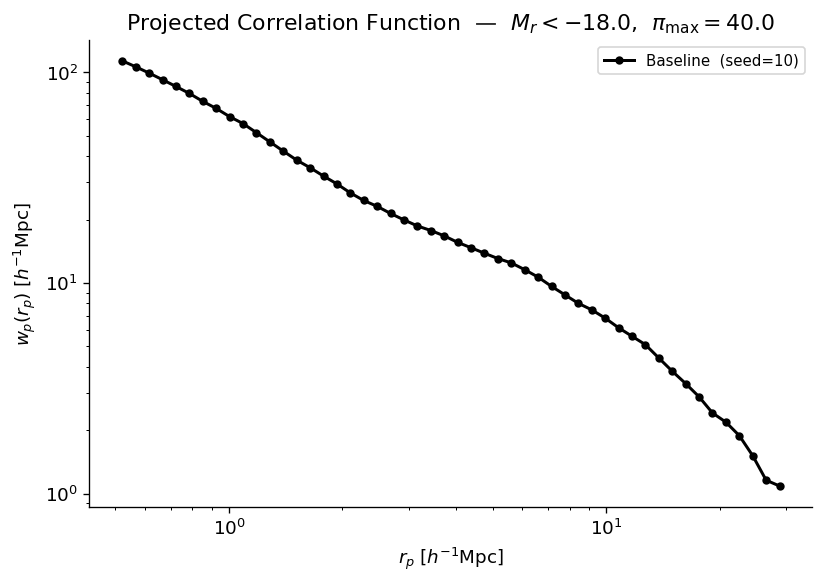

Computing wp for centrals only...
Computing wp for satellites only...


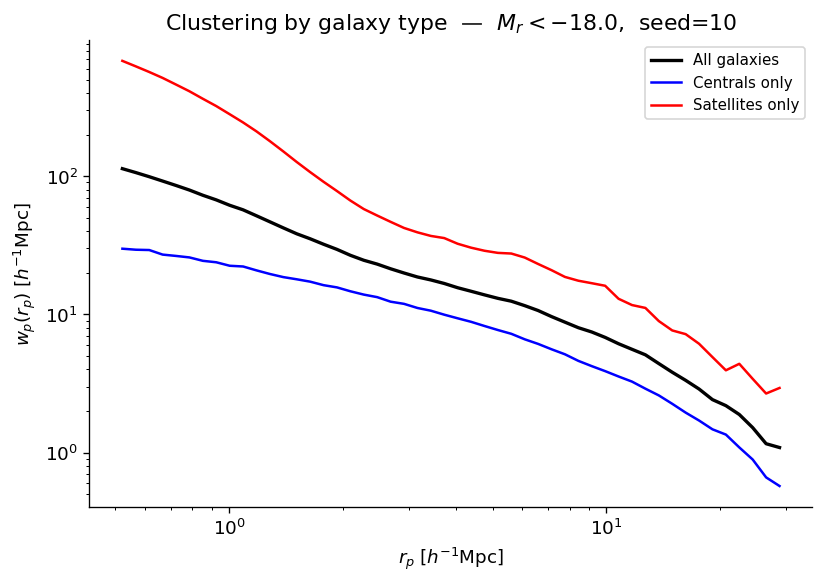

✓ Chapter 8 complete — compute_wp() validated.
   wp_base is the observable used for all downstream derivatives.


In [10]:
RP_BINS = np.logspace(np.log10(RP_MIN), np.log10(RP_MAX), N_RP + 1)


def compute_wp(mock, lbox=None, pimax=None, rp_bins=None, nthreads=None):
    """
    Compute the projected correlation function w_p(r_p) for a mock catalogue.

    Parameters
    ----------
    mock     : dict  output of generate_mock() — must have keys 'x', 'y', 'z'
    lbox     : float [Mpc/h]  (default LBOX)
    pimax    : float [Mpc/h]  (default PIMAX)
    rp_bins  : ndarray        (default RP_BINS)
    nthreads : int            (default NTHREADS)

    Returns
    -------
    rp : ndarray (N_RP,)  bin-averaged r_p [h⁻¹ Mpc]
    wp : ndarray (N_RP,)  projected correlation function [h⁻¹ Mpc]
    """
    if lbox     is None: lbox     = LBOX
    if pimax    is None: pimax    = PIMAX
    if rp_bins  is None: rp_bins  = RP_BINS
    if nthreads is None: nthreads = NTHREADS

    x = mock['x'].astype(np.float64)
    y = mock['y'].astype(np.float64)
    z = mock['z'].astype(np.float64)

    results = corrfunc_wp(
        lbox, pimax, nthreads,
        binfile    = rp_bins,
        X=x, Y=y, Z=z,
        output_rpavg = True,
    )
    rp_arr = np.array([r['rpavg'] for r in results])
    wp_arr = np.array([r['wp']    for r in results])
    return rp_arr, wp_arr


# ── Baseline wp ──────────────────────────────────────────────
print('Computing baseline wp(rp)...')
rp_base, wp_base = compute_wp(mock_base)

# ── Sanity checks ────────────────────────────────────────────
assert np.all(wp_base > 0),             'wp has non-positive values'
assert np.all(np.diff(rp_base) > 0),    'rp bins not monotonically increasing'
assert rp_base[0]  > RP_MIN * 0.9,      'first rp bin too low'
assert rp_base[-1] < RP_MAX * 1.1,      'last rp bin too high'

# wp should be decreasing (clustering weaker at larger scales)
assert wp_base[0] > wp_base[-1], 'wp not decreasing — clustering problem'

print(f'  N_RP = {len(rp_base)}  rp in [{rp_base[0]:.3f}, {rp_base[-1]:.3f}] Mpc/h')
print(f'  wp   in [{wp_base.min():.2f}, {wp_base.max():.2f}] Mpc/h')
print()

# ── Print table ──────────────────────────────────────────────
print(f"{'bin':>4}  {'rp [Mpc/h]':>12}  {'wp [Mpc/h]':>12}")
print('-' * 34)
for i, (rp_i, wp_i) in enumerate(zip(rp_base, wp_base)):
    print(f'{i:>4}  {rp_i:>12.4f}  {wp_i:>12.4f}')
print()

# ── Figure 1: baseline wp ────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(7, 5))
ax1.loglog(rp_base, wp_base, 'ko-', ms=4, lw=1.8,
           label=f'Baseline  (seed={SEED})')
ax1.set_xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
ax1.set_ylabel(r'$w_p(r_p)\;[h^{-1}\mathrm{Mpc}]$')
ax1.set_title(f'Projected Correlation Function  —  $M_r < {MR_THRESH}$,  $\\pi_{{\\max}}={PIMAX}$')
ax1.legend(fontsize=9)
plt.tight_layout(); plt.show()

# ── All / Centrals / Satellites trio ─────────────────────────
print('Computing wp for centrals only...')
rp_cen, wp_cen = compute_wp({
    'x': mock_base['x'][ mock_base['is_central']],
    'y': mock_base['y'][ mock_base['is_central']],
    'z': mock_base['z'][ mock_base['is_central']],
})

print('Computing wp for satellites only...')
rp_sat, wp_sat = compute_wp({
    'x': mock_base['x'][~mock_base['is_central']],
    'y': mock_base['y'][~mock_base['is_central']],
    'z': mock_base['z'][~mock_base['is_central']],
})

# Satellites above centrals at small rp (1-halo term)
assert wp_sat[0] > wp_cen[0], 'Satellites not above centrals at small rp'

fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.loglog(rp_base, wp_base, 'k-', lw=2,   label='All galaxies')
ax2.loglog(rp_cen,  wp_cen,  'b-', lw=1.5, label='Centrals only')
ax2.loglog(rp_sat,  wp_sat,  'r-', lw=1.5, label='Satellites only')
ax2.set_xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
ax2.set_ylabel(r'$w_p(r_p)\;[h^{-1}\mathrm{Mpc}]$')
ax2.set_title(f'Clustering by galaxy type  —  $M_r < {MR_THRESH}$,  seed={SEED}')
ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

print('✓ Chapter 8 complete — compute_wp() validated.')
print('   wp_base is the observable used for all downstream derivatives.')


Building luminosity catalogue...
... assigning central luminosities
... assigning satellite luminosities

centrals  :  207,998
satellites:  102,687

Range checks:
  centrals  Mr in [-23.5, -18.0] : True
  satellites Mr in [-23.5, -18.0] : True



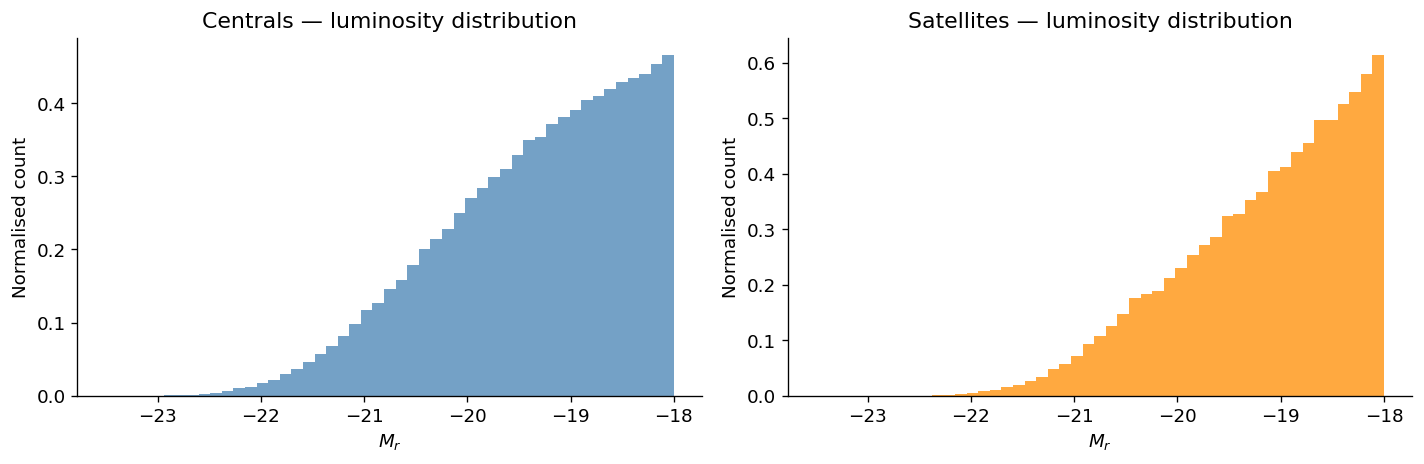

✓ Chapter 9 complete — luminosity catalogue built and validated.


In [11]:
class LuminosityAssigner:
    """
    Assign absolute magnitudes Mr to central and satellite galaxies
    via nested-HOD inverse-transform sampling.

    Scientific basis: Smith et al. (2024) BGS HOD.
        P(Lcen > L | M) ∝ fcen_thresh(lgm, hod_params_at_L)   [cumulative in L]
        P(Lsat > L | M) ∝ Nsat_thresh(lgm, hod_params_at_L)   [cumulative in L]

    The central occupation uses F_spline (BGS model), NOT erf.

    HOD equations are NOT re-implemented here — this class delegates
    entirely to fcen_thresh() and Nsat_thresh() from Chapter 5.

    Parameters
    ----------
    Mrmax : float   faint-end luminosity threshold (e.g. -20.0)
    seed  : int     RNG seed (default 42)
    dMr   : float   grid spacing in magnitude (default 0.001)
    """

    def __init__(self, Mrmax, seed=42, dMr=0.001):
        self.Mrmax = Mrmax
        self.rng   = np.random.RandomState(seed=seed)

        # Fine magnitude grid: bright (-23.5) → threshold
        nMr          = int((23.5 + Mrmax) / dMr)
        self.Mrvals  = np.linspace(-23.5, Mrmax, nMr)
        self.dMr     = self.Mrvals[1] - self.Mrvals[0]

        # Pre-compute HOD parameters on the Mr grid (once at construction)
        # get_hod_params() is the single source of truth for Smith et al. coefficients
        self._hod_grid = get_hod_params(self.Mrvals)   # dict of arrays, shape (nMr,)
        self._hod_max  = get_hod_params(self.Mrmax)    # dict of scalars, normalisation

    # ── Central luminosity assignment ─────────────────────────

    def assign_central_luminosity(self, lgm_halos):
        """
        Assign Mr to each central galaxy via inverse-transform sampling
        of the BGS cumulative central occupation (F_spline, not erf).

        Parameters
        ----------
        lgm_halos : array (N_cen,)   log10(halo mass) of occupied halos

        Returns
        -------
        Mr_cen : array (N_cen,)
        """
        n      = lgm_halos.size
        Mr_cen = np.zeros(n, dtype=float)
        u      = self.rng.rand(n)
        nmax   = self.Mrvals.size - 1

        # Normalisation: fcen at the faint threshold for each halo
        Pnorm = fcen_thresh(lgm_halos, self._hod_max)   # shape (N_cen,)

        for h in range(n):
            # Cumulative probability along the Mr grid, normalised to [0,1]
            PcenL = fcen_thresh(lgm_halos[h], self._hod_grid) / Pnorm[h]
            idx   = min(np.searchsorted(PcenL, u[h], side='right'), nmax)
            Mr_cen[h] = self.Mrvals[idx]

        return Mr_cen

    # ── Satellite luminosity assignment ───────────────────────

    def assign_satellite_luminosities(self, centrals, h):
        """
        Assign Mr to all satellites in halo h via inverse-transform sampling
        of the cumulative satellite occupation (power-law Nsat).

        Parameters
        ----------
        centrals : structured array   with fields 'Nsat', 'lgm'
        h        : int                halo index into centrals

        Returns
        -------
        Mr_sat : array (Nsat_h,)
        """
        Nsat_h   = centrals['Nsat'][h]
        lgmhalo  = centrals['lgm'][h]

        # Cumulative satellite count along the Mr grid, normalised at threshold
        PsatL = Nsat_thresh(lgmhalo, self._hod_grid)    # shape (nMr,)
        norm  = Nsat_thresh(lgmhalo, self._hod_max)     # scalar

        if norm <= 0.0:
            return np.full(Nsat_h, self.Mrmax)

        PsatL /= norm
        u   = self.rng.rand(Nsat_h)
        idx = np.clip(np.searchsorted(PsatL, u, side='left'), 0, self.Mrvals.size - 1)
        return self.Mrvals[idx]


# ── Build centrals / satellites structured arrays ─────────────
print('Building luminosity catalogue...')
mm = LuminosityAssigner(Mrmax=MR_THRESH, seed=42)

# Centrals: all halos that received a central galaxy in mock_base
cen_halo_idx = mock_base['halo_idx'][mock_base['is_central']]

centrals = np.zeros(cen_halo_idx.size, dtype=[
    ('haloid', 'int64'), ('lgm', 'f8'),
    ('x', 'f8'), ('y', 'f8'), ('z', 'f8'),
    ('Mr', 'f8'), ('Nsat', 'i4'),
])
centrals['haloid'] = cen_halo_idx
centrals['lgm']    = np.log10(halos[MASSDEF][cen_halo_idx])
centrals['x']      = mock_base['x'][mock_base['is_central']]
centrals['y']      = mock_base['y'][mock_base['is_central']]
centrals['z']      = mock_base['z'][mock_base['is_central']]

# Satellite counts per central halo (from mock_base)
nsat_per_halo = np.zeros(halos.size, dtype=int)
sat_hidx = mock_base['halo_idx'][~mock_base['is_central']]
np.add.at(nsat_per_halo, sat_hidx, 1)
centrals['Nsat'] = nsat_per_halo[cen_halo_idx]

print('... assigning central luminosities')
centrals['Mr'] = mm.assign_central_luminosity(centrals['lgm'])

# Satellites structured array
Nsat_tot = int(centrals['Nsat'].sum())
satellites = np.zeros(Nsat_tot, dtype=[
    ('haloid', 'int64'), ('lgm', 'f8'),
    ('x', 'f8'), ('y', 'f8'), ('z', 'f8'),
    ('Mr', 'f8'),
])

# Fill satellite positions from mock_base (already NFW-sampled)
sat_mask  = ~mock_base['is_central']
satellites['x']      = mock_base['x'][sat_mask]
satellites['y']      = mock_base['y'][sat_mask]
satellites['z']      = mock_base['z'][sat_mask]
satellites['haloid'] = mock_base['halo_idx'][sat_mask]
satellites['lgm']    = np.log10(halos[MASSDEF][satellites['haloid'].astype(int)])

print('... assigning satellite luminosities')
s_lo = 0
for h in range(centrals.size):
    s_hi = s_lo + centrals['Nsat'][h]
    if centrals['Nsat'][h] > 0:
        satellites['Mr'][s_lo:s_hi] = mm.assign_satellite_luminosities(centrals, h)
    s_lo = s_hi

# ── Validation ────────────────────────────────────────────────
print()
print(f'centrals  : {centrals.size:>8,}')
print(f'satellites: {satellites.size:>8,}')
print()
print('Range checks:')
cen_ok = np.all((centrals['Mr']  >= -23.5) & (centrals['Mr']  <= MR_THRESH))
sat_ok = np.all((satellites['Mr'] >= -23.5) & (satellites['Mr'] <= MR_THRESH))
print(f'  centrals  Mr in [-23.5, {MR_THRESH}] : {cen_ok}')
print(f'  satellites Mr in [-23.5, {MR_THRESH}] : {sat_ok}')
assert cen_ok, 'Central Mr out of range'
assert sat_ok, 'Satellite Mr out of range'
print()

# Mr distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins_mr = np.linspace(-23.5, MR_THRESH, 50)
for ax, arr, label, col in zip(
        axes,
        [centrals['Mr'], satellites['Mr']],
        ['Centrals', 'Satellites'],
        ['steelblue', 'darkorange']):
    ax.hist(arr, bins=bins_mr, color=col, alpha=0.75, density=True)
    ax.set_xlabel(r'$M_r$'); ax.set_ylabel('Normalised count')
    ax.set_title(f'{label} — luminosity distribution')
plt.tight_layout(); plt.show()

print('✓ Chapter 9 complete — luminosity catalogue built and validated.')


In [12]:
# The five parameters we differentiate with respect to.
# Names match the keys returned by get_hod_params().
HOD_PARAM_NAMES = ['Mcut', 'M1', 'M0', 'sigma', 'alpha']

# Two step sizes for convergence check
DELTAS = [0.050, 0.025]

# 'Stable' step used for multi-seed averaging of noisy parameters (Ch 11b)
DELTA_STABLE = 0.025


def perturb_params(hod_params, param_name, factor):
    """
    Return a new HOD parameter dict with one parameter multiplied by `factor`.

    Does NOT mutate the input dict.

    Parameters
    ----------
    hod_params : dict    baseline HOD parameters (e.g. BASE_HOD)
    param_name : str     key to perturb (must be in HOD_PARAM_NAMES)
    factor     : float   multiplicative factor (e.g. 1.05, 0.95)

    Returns
    -------
    dict  — new parameter dict, same keys as hod_params
    """
    new_params = dict(hod_params)          # shallow copy — scalars, so safe
    new_params[param_name] = hod_params[param_name] * factor
    return new_params


# ── Validation: perturb_params must not mutate BASE_HOD ──────
_base_before = dict(BASE_HOD)
_test_perturbed = perturb_params(BASE_HOD, 'Mcut', 1.05)
assert BASE_HOD == _base_before,                          'perturb_params mutated BASE_HOD!'
assert _test_perturbed['Mcut'] != BASE_HOD['Mcut'],       'perturbation not applied'
assert _test_perturbed['M1']   == BASE_HOD['M1'],         'unperturbed param changed'
print('perturb_params immutability check: ✓')
print()

# ── Perturbation table ────────────────────────────────────────
print(f"Perturbation table  (baseline Mr = {MR_THRESH}):")
print(f"{'Param':<8}  {'Baseline':>14}  ", end='')
for delta in DELTAS:
    print(f"  {f'+{100*delta:.1f}%':>10}  {f'-{100*delta:.1f}%':>10}", end='')
print()
print('-' * 80)
for pname in HOD_PARAM_NAMES:
    base_val = BASE_HOD[pname]
    print(f"{pname:<8}  {base_val:>14.6g}", end='')
    for delta in DELTAS:
        p_plus  = perturb_params(BASE_HOD, pname, 1 + delta)
        p_minus = perturb_params(BASE_HOD, pname, 1 - delta)
        print(f"  {p_plus[pname]:>10.6g}  {p_minus[pname]:>10.6g}", end='')
    print()
print()
print('✓ Chapter 10 complete — perturbation framework validated.')


perturb_params immutability check: ✓

Perturbation table  (baseline Mr = -18.0):
Param           Baseline         +5.0%       -5.0%       +2.5%       -2.5%
--------------------------------------------------------------------------------
Mcut         1.42569e+11  1.49697e+11  1.3544e+11  1.46133e+11  1.39005e+11
M1           2.83813e+12  2.98004e+12  2.69623e+12  2.90909e+12  2.76718e+12
M0            1.2764e+07  1.34022e+07  1.21258e+07  1.30831e+07  1.24449e+07
sigma          0.0710564   0.0746092   0.0675035   0.0728328   0.0692799
alpha            1.11194     1.16754     1.05634     1.13974     1.08414

✓ Chapter 10 complete — perturbation framework validated.



── Mcut  δ = ±5.0% ──
  Mcut: 1.42569e+11 → +5.0%: 1.49697e+11  |  -5.0%: 1.3544e+11
  N_gal: +5.0% = 301,454   -5.0% = 321,892

── Mcut  δ = ±2.5% ──
  Mcut: 1.42569e+11 → +2.5%: 1.46133e+11  |  -2.5%: 1.39005e+11
  N_gal: +2.5% = 306,004   -2.5% = 316,162

── M1  δ = ±5.0% ──
  M1: 2.83813e+12 → +5.0%: 2.98004e+12  |  -5.0%: 2.69623e+12
  N_gal: +5.0% = 305,564   -5.0% = 316,740

── M1  δ = ±2.5% ──
  M1: 2.83813e+12 → +2.5%: 2.90909e+12  |  -2.5%: 2.76718e+12
  N_gal: +2.5% = 307,948   -2.5% = 313,916

── M0  δ = ±5.0% ──
  M0: 1.2764e+07 → +5.0%: 1.34022e+07  |  -5.0%: 1.21258e+07
  N_gal: +5.0% = 310,685   -5.0% = 310,658

── M0  δ = ±2.5% ──
  M0: 1.2764e+07 → +2.5%: 1.30831e+07  |  -2.5%: 1.24449e+07
  N_gal: +2.5% = 310,685   -2.5% = 310,685

── sigma  δ = ±5.0% ──
  sigma: 0.0710564 → +5.0%: 0.0746092  |  -5.0%: 0.0675035
  N_gal: +5.0% = 310,544   -5.0% = 310,493

── sigma  δ = ±2.5% ──
  sigma: 0.0710564 → +2.5%: 0.0728328  |  -2.5%: 0.0692799
  N_gal: +2.5% = 310,842   -2.

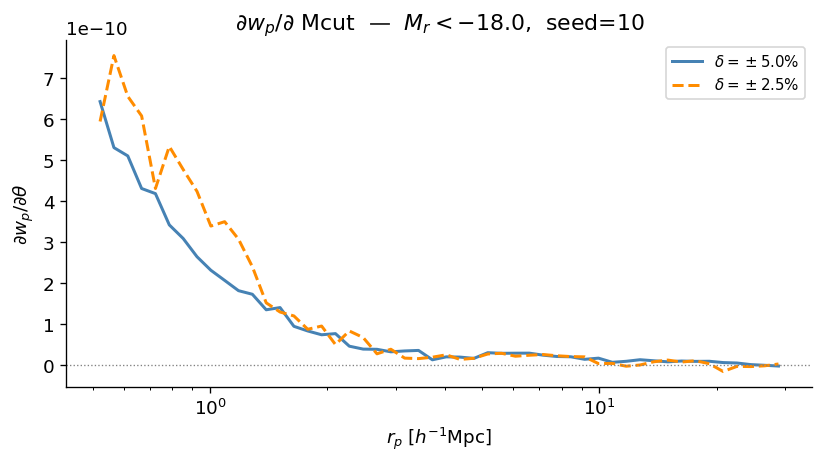

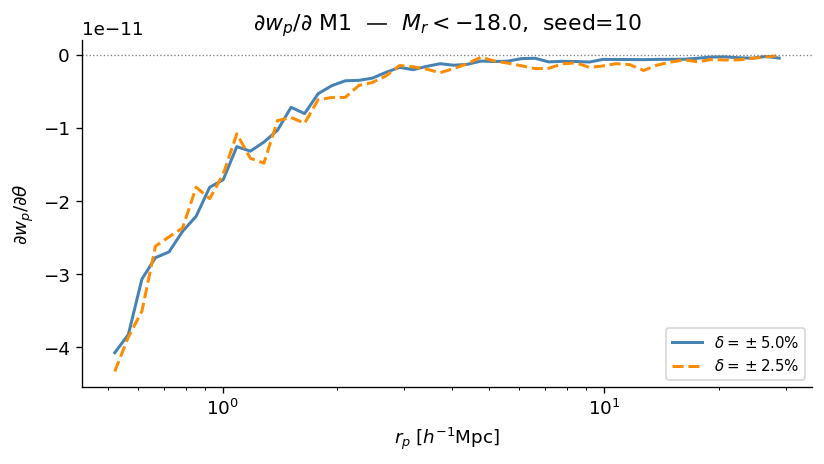

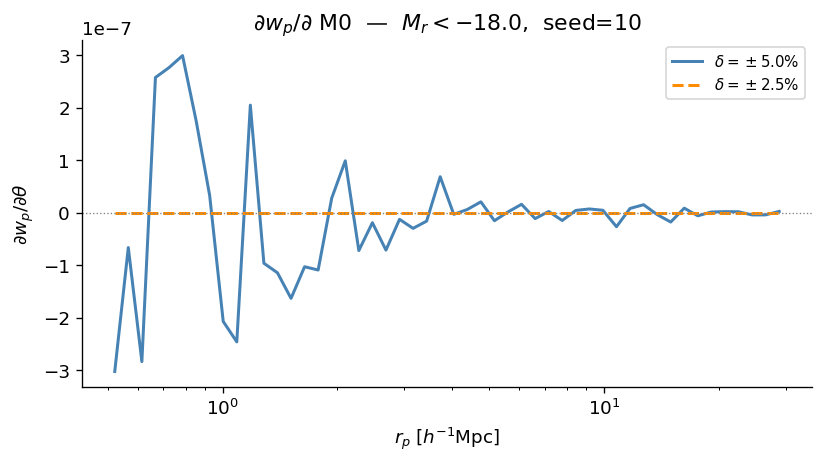

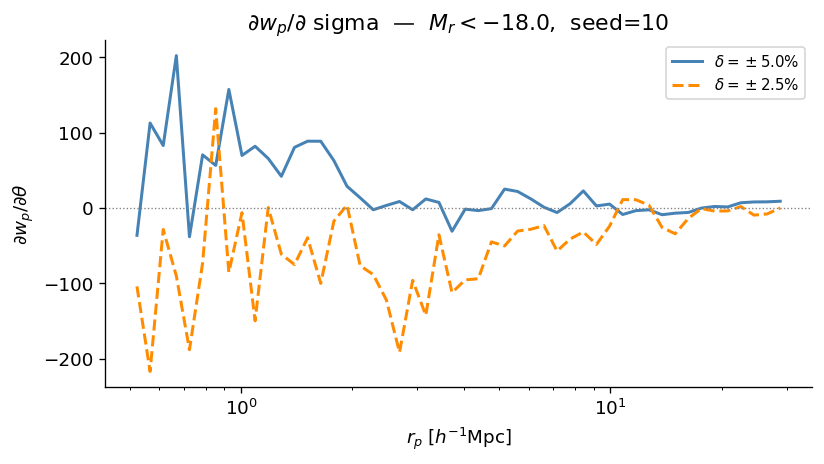

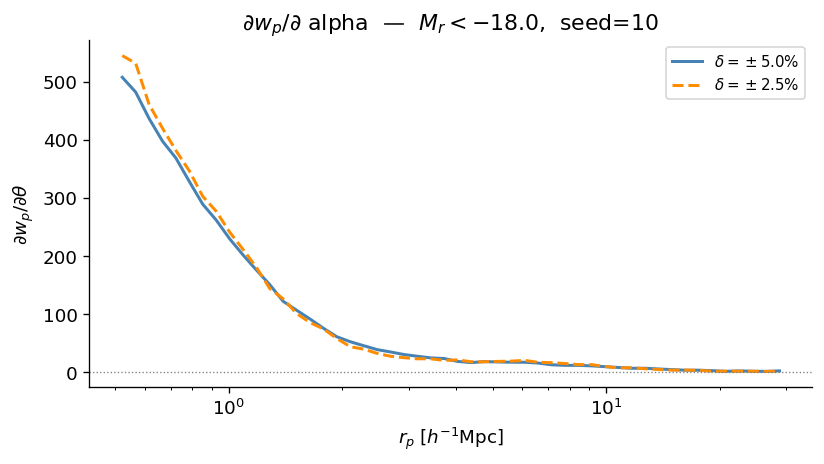


=== Step-size convergence check ===
  Max |d5% − d2.5%| / max(|d5%|, |d2.5%|) per parameter

  Parameter    Max rel. diff    Converged?
  ----------------------------------------
  Mcut                0.0000  ✓
  M1                  0.0000  ✓
  M0                  1.0000  ✗  → needs averaging (Ch 11b)
  sigma               1.9660  ✗  → needs averaging (Ch 11b)
  alpha               0.3572  ✗  → needs averaging (Ch 11b)

Parameters requiring multi-seed averaging: ['M0', 'sigma', 'alpha']

✓ Chapter 11 complete — derivative engine run.


In [13]:

# derivs[param][delta] = (rp_array, dwp_array)
derivs       = {p: {} for p in HOD_PARAM_NAMES}
wp_results   = {p: {} for p in HOD_PARAM_NAMES}

for param in HOD_PARAM_NAMES:
    for delta in DELTAS:
        p_plus  = perturb_params(BASE_HOD, param, 1.0 + delta)
        p_minus = perturb_params(BASE_HOD, param, 1.0 - delta)

        print(f'\n── {param}  δ = ±{100*delta:.1f}% ──')
        print(f'  {param}: {BASE_HOD[param]:.6g} → +{100*delta:.1f}%: {p_plus[param]:.6g}'
              f'  |  -{100*delta:.1f}%: {p_minus[param]:.6g}')

        mock_plus  = generate_mock(halos, p_plus,  seed=SEED, verbose=False)
        mock_minus = generate_mock(halos, p_minus, seed=SEED, verbose=False)

        ngal_p = mock_plus['ncen_total']  + mock_plus['nsat_total']
        ngal_m = mock_minus['ncen_total'] + mock_minus['nsat_total']
        print(f'  N_gal: +{100*delta:.1f}% = {ngal_p:,}   -{100*delta:.1f}% = {ngal_m:,}')

        rp_p, wp_p = compute_wp(mock_plus)
        rp_m, wp_m = compute_wp(mock_minus)

        wp_results[param][delta] = (rp_p, wp_p, wp_m)

        dtheta = BASE_HOD[param] * 2.0 * delta
        dwp    = (wp_p - wp_m) / dtheta
        derivs[param][delta] = (rp_p, dwp)

        del mock_plus, mock_minus
        gc.collect()

# ── Per-parameter derivative plots ───────────────────────────
print('\n\nDerivative plots:')
for param in HOD_PARAM_NAMES:
    fig, ax = plt.subplots(figsize=(7, 4))
    for delta, ls, col in zip(DELTAS, ['-', '--'], ['steelblue', 'darkorange']):
        rp, dwp = derivs[param][delta]
        ax.plot(rp, dwp, ls=ls, color=col, lw=1.8,
                label=f'$\\delta = \\pm{100*delta:.1f}\\%$')
    ax.axhline(0, color='gray', lw=0.8, ls=':')
    ax.set_xscale('log')
    ax.set_xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
    ax.set_ylabel(r'$\partial w_p / \partial\theta$')
    ax.set_title(f'$\\partial w_p / \\partial$ {param}  —  $M_r < {MR_THRESH}$,  seed={SEED}')
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

# ── Convergence table ────────────────────────────────────────
CONVERGENCE_TOL = 0.15

print('\n=== Step-size convergence check ===')
print('  Max |d5% − d2.5%| / max(|d5%|, |d2.5%|) per parameter')
print()
print(f"  {'Parameter':<10}  {'Max rel. diff':>14}  {'Converged?':>12}")
print('  ' + '-' * 40)

NOISY_PARAMS = []   # parameters that need multi-seed averaging (Ch 11b)
all_converged = True
for param in HOD_PARAM_NAMES:
    _, d5  = derivs[param][0.050]
    _, d25 = derivs[param][0.025]
    denom  = np.maximum(np.abs(d5), np.abs(d25))
    mask   = denom > 1e-8
    rel_diff = np.max(np.abs(d5[mask] - d25[mask]) / denom[mask]) if mask.any() else 0.0
    ok = rel_diff < CONVERGENCE_TOL
    if not ok:
        NOISY_PARAMS.append(param)
    all_converged &= ok
    flag = '✓' if ok else '✗  → needs averaging (Ch 11b)'
    print(f"  {param:<10}  {rel_diff:>14.4f}  {flag}")

print()
if all_converged:
    print('All derivatives converged within 15% — no averaging needed.')
else:
    print(f'Parameters requiring multi-seed averaging: {NOISY_PARAMS}')
print('\n✓ Chapter 11 complete — derivative engine run.')


In [15]:
# We test on 'sigma' (siglgM in old notation) as it reliably shows drift.
# If NOISY_PARAMS is empty (all converged in Ch 11), this cell still runs
# as a scientific demonstration.

_diag_param = 'sigma'
p_plus  = perturb_params(BASE_HOD, _diag_param, 1.0 + DELTA_STABLE)
p_minus = perturb_params(BASE_HOD, _diag_param, 1.0 - DELTA_STABLE)

mock_diag_p = generate_mock(halos, p_plus,  seed=SEED, verbose=False)
mock_diag_m = generate_mock(halos, p_minus, seed=SEED, verbose=False)

# Count satellites per halo in each mock
nsat_diag_p = np.zeros(halos.size, dtype=int)
nsat_diag_m = np.zeros(halos.size, dtype=int)
np.add.at(nsat_diag_p, mock_diag_p['halo_idx'][~mock_diag_p['is_central']], 1)
np.add.at(nsat_diag_m, mock_diag_m['halo_idx'][~mock_diag_m['is_central']], 1)

# Halos where N_sat is identical in both variants
same_nsat = (nsat_diag_p == nsat_diag_m) & (nsat_diag_p > 0)
print(f'Parameter tested        : {_diag_param}')
print(f'Halos with same N_sat   : {same_nsat.sum():,}')

# For a sample of those halos, check whether satellite POSITIONS differ
sample_idx = np.where(same_nsat)[0][:20]
mismatches = 0
for hidx in sample_idx:
    mask_p = (mock_diag_p['halo_idx'] == hidx) & ~mock_diag_p['is_central']
    mask_m = (mock_diag_m['halo_idx'] == hidx) & ~mock_diag_m['is_central']
    pos_p = np.column_stack([mock_diag_p['x'][mask_p],
                             mock_diag_p['y'][mask_p],
                             mock_diag_p['z'][mask_p]])
    pos_m = np.column_stack([mock_diag_m['x'][mask_m],
                             mock_diag_m['y'][mask_m],
                             mock_diag_m['z'][mask_m]])
    # Sort by position to compare regardless of internal ordering
    pos_p_s = pos_p[np.lexsort(pos_p.T)]
    pos_m_s = pos_m[np.lexsort(pos_m.T)]
    if not np.allclose(pos_p_s, pos_m_s, atol=1e-8):
        mismatches += 1

print(f'Halos with same N_sat but DIFFERENT positions: {mismatches}/{len(sample_idx)}')
print()
if mismatches > 0:
    print('RNG STREAM DRIFT CONFIRMED.')
    print('  Halos with identical N_sat still get different satellite positions.')
    print('  This is caused by np.random.poisson consuming variable RNG bits')
    print('  depending on lambda, which shifts the stream entering gen_NFW_profile.')
    print('  Fix: average over multiple seeds (Cell 2 below).')
else:
    print('No drift detected in this sample.')
    print('  The noise floor for sigma/M0/alpha is likely genuine sampling noise.')
    print('  Multi-seed averaging (Cell 2) is still the correct fix.')

del mock_diag_p, mock_diag_m
gc.collect()


Parameter tested        : sigma
Halos with same N_sat   : 12,804
Halos with same N_sat but DIFFERENT positions: 20/20

RNG STREAM DRIFT CONFIRMED.
  Halos with identical N_sat still get different satellite positions.
  This is caused by np.random.poisson consuming variable RNG bits
  depending on lambda, which shifts the stream entering gen_NFW_profile.
  Fix: average over multiple seeds (Cell 2 below).


0

In [16]:
N_REALIZATIONS = 15   # number of random seeds to average over

# Stack of wp arrays for each realization: keyed by parameter
wp_plus_stack_all  = {p: [] for p in NOISY_PARAMS}
wp_minus_stack_all = {p: [] for p in NOISY_PARAMS}

if not NOISY_PARAMS:
    print('No noisy parameters identified in Ch 11 — skipping multi-seed loop.')
    print('If you want to run this cell anyway, manually set:')
    print("  NOISY_PARAMS = ['sigma', 'M0', 'alpha']")
else:
    for real_seed in range(N_REALIZATIONS):
        print(f'\n── Realization {real_seed+1:2d}/{N_REALIZATIONS}  (seed={real_seed}) ──')
        for param in NOISY_PARAMS:
            p_plus  = perturb_params(BASE_HOD, param, 1.0 + DELTA_STABLE)
            p_minus = perturb_params(BASE_HOD, param, 1.0 - DELTA_STABLE)

            mock_plus  = generate_mock(halos, p_plus,  seed=real_seed, verbose=False)
            mock_minus = generate_mock(halos, p_minus, seed=real_seed, verbose=False)

            _, wp_p = compute_wp(mock_plus)
            _, wp_m = compute_wp(mock_minus)

            wp_plus_stack_all[param].append(wp_p)
            wp_minus_stack_all[param].append(wp_m)

            del mock_plus, mock_minus
            gc.collect()

    # ── Compute averaged derivatives ──────────────────────────
    derivs_averaged = {}
    print('\n\n=== Averaged derivatives ===')
    for param in NOISY_PARAMS:
        wp_plus_mean  = np.mean(wp_plus_stack_all[param],  axis=0)
        wp_minus_mean = np.mean(wp_minus_stack_all[param], axis=0)
        wp_plus_std   = np.std( wp_plus_stack_all[param],  axis=0, ddof=1)
        wp_minus_std  = np.std( wp_minus_stack_all[param], axis=0, ddof=1)

        dtheta   = BASE_HOD[param] * 2.0 * DELTA_STABLE
        dwp_mean = (wp_plus_mean - wp_minus_mean) / dtheta
        dwp_err  = np.sqrt(wp_plus_std**2 + wp_minus_std**2) / (
                       dtheta * np.sqrt(N_REALIZATIONS))

        # rp array comes from the single-realization derivative
        rp_ref, _ = derivs[param][DELTA_STABLE]
        derivs_averaged[param] = (rp_ref, dwp_mean, dwp_err)

        _, dwp_single = derivs[param][DELTA_STABLE]
        rel_change = np.max(np.abs(dwp_mean - dwp_single)) / max(
            np.max(np.abs(dwp_mean)), 1e-30)
        print(f'  {param:<8}  max rel change vs single-realization: {rel_change:.4f}')

    print(f'\nAveraging complete ({N_REALIZATIONS} realizations).')



── Realization  1/15  (seed=0) ──

── Realization  2/15  (seed=1) ──

── Realization  3/15  (seed=2) ──

── Realization  4/15  (seed=3) ──

── Realization  5/15  (seed=4) ──

── Realization  6/15  (seed=5) ──

── Realization  7/15  (seed=6) ──

── Realization  8/15  (seed=7) ──

── Realization  9/15  (seed=8) ──

── Realization 10/15  (seed=9) ──

── Realization 11/15  (seed=10) ──

── Realization 12/15  (seed=11) ──

── Realization 13/15  (seed=12) ──

── Realization 14/15  (seed=13) ──

── Realization 15/15  (seed=14) ──


=== Averaged derivatives ===
  M0        max rel change vs single-realization: 1.0000
  sigma     max rel change vs single-realization: 1.8595
  alpha     max rel change vs single-realization: 0.1491

Averaging complete (15 realizations).


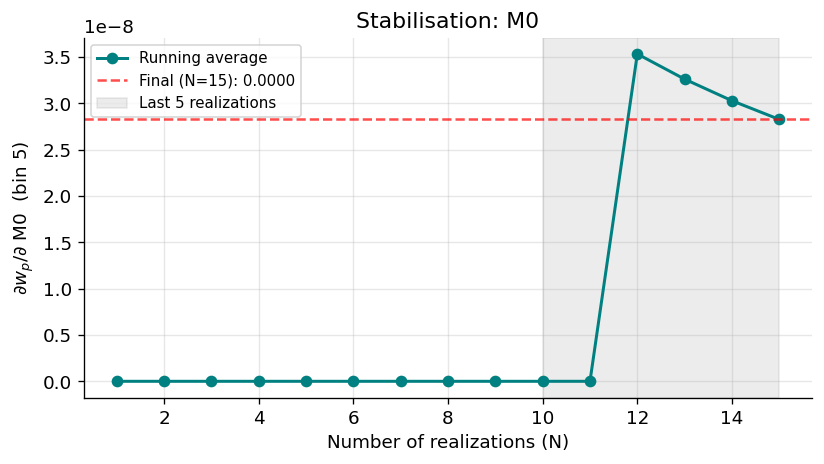

Saved: results/stabilization_M0.png


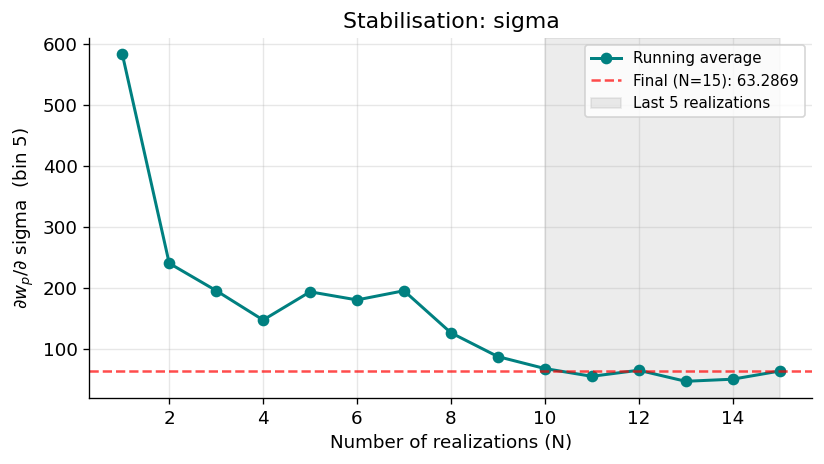

Saved: results/stabilization_sigma.png


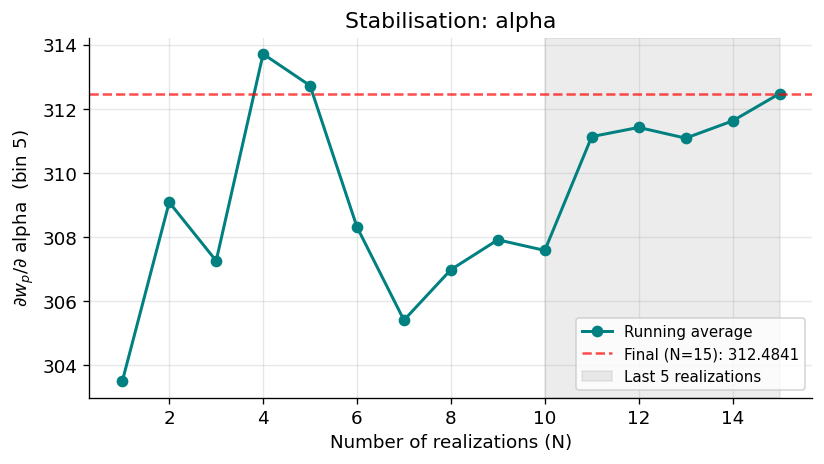

Saved: results/stabilization_alpha.png

=== Convergence summary ===
  Parameter     Rel. change (last 5)              Status
  -------------------------------------------------------
  M0                         100.00%   STILL STABILISING
  sigma                        6.59%   STILL STABILISING
  alpha                        1.57%           CONVERGED

✓ Chapter 11b complete — RNG drift diagnosed, averaging complete.


In [17]:
STABILIZATION_WINDOW = 5    # check stability over last N iterations
STABILIZATION_TOL    = 0.05  # 5% relative change threshold for convergence
bin_idx = 5                  # which rp bin to monitor (representative)

convergence_summary = {}

if not NOISY_PARAMS:
    print('No noisy parameters — stabilisation plot skipped.')
else:
    for param in NOISY_PARAMS:
        p_plus_arr  = np.array(wp_plus_stack_all[param])
        p_minus_arr = np.array(wp_minus_stack_all[param])
        dtheta = BASE_HOD[param] * 2.0 * DELTA_STABLE

        running = []
        for n in range(1, N_REALIZATIONS + 1):
            avg_plus  = np.mean(p_plus_arr[:n],  axis=0)
            avg_minus = np.mean(p_minus_arr[:n], axis=0)
            deriv     = (avg_plus - avg_minus) / dtheta
            running.append(deriv[bin_idx])
        running = np.array(running)

        n_final    = N_REALIZATIONS
        n_ref      = max(1, n_final - STABILIZATION_WINDOW)
        val_final  = running[n_final - 1]
        val_ref    = running[n_ref - 1]
        rel_change = abs(val_final - val_ref) / max(abs(val_final), 1e-30)
        is_conv    = rel_change < STABILIZATION_TOL
        convergence_summary[param] = (rel_change, is_conv)

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(range(1, N_REALIZATIONS+1), running,
                marker='o', lw=1.8, color='teal', ms=6, label='Running average')
        ax.axhline(val_final, color='red', ls='--', alpha=0.7, lw=1.5,
                   label=f'Final (N={n_final}): {val_final:.4f}')
        ax.axvspan(n_ref, n_final, color='gray', alpha=0.15,
                   label=f'Last {STABILIZATION_WINDOW} realizations')
        ax.set_xlabel('Number of realizations (N)')
        ax.set_ylabel(f'$\\partial w_p/\\partial$ {param}  (bin {bin_idx})')
        ax.set_title(f'Stabilisation: {param}')
        ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
        plt.tight_layout()
        outpath = OUTPUT_DIR / f'stabilization_{param}.png'
        plt.savefig(outpath, dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Saved: {outpath}')

    print('\n=== Convergence summary ===')
    print(f"  {'Parameter':<10}  {'Rel. change (last 5)':>22}  {'Status':>18}")
    print('  ' + '-' * 55)
    for param in NOISY_PARAMS:
        rel_change, ok = convergence_summary[param]
        status = 'CONVERGED' if ok else 'STILL STABILISING'
        print(f"  {param:<10}  {100*rel_change:>21.2f}%  {status:>18}")

print('\n✓ Chapter 11b complete — RNG drift diagnosed, averaging complete.')


FINAL DERIVATIVES   d(wp) / d(theta)
Sample: Mr < -18.0,  seed = 10,  pimax = 40.0 h⁻¹ Mpc
Method per parameter:
  Mcut     : single-realization  δ=±2.5%
  M1       : single-realization  δ=±2.5%
  M0       : averaged  N=15  δ=±2.5%
  sigma    : averaged  N=15  δ=±2.5%
  alpha    : averaged  N=15  δ=±2.5%

        rp            Mcut              M1              M0           sigma           alpha
------------------------------------------------------------------------------------------
    0.5215          0.0000         -0.0000          0.0000        158.4219        497.9790
    0.5660          0.0000         -0.0000         -0.0000         77.7992        457.5841
    0.6143          0.0000         -0.0000         -0.0000         77.7258        424.9051
    0.6666          0.0000         -0.0000         -0.0000        126.0865        386.7975
    0.7236          0.0000         -0.0000          0.0000         27.1148        347.3037
    0.7853          0.0000         -0.0000          0.00

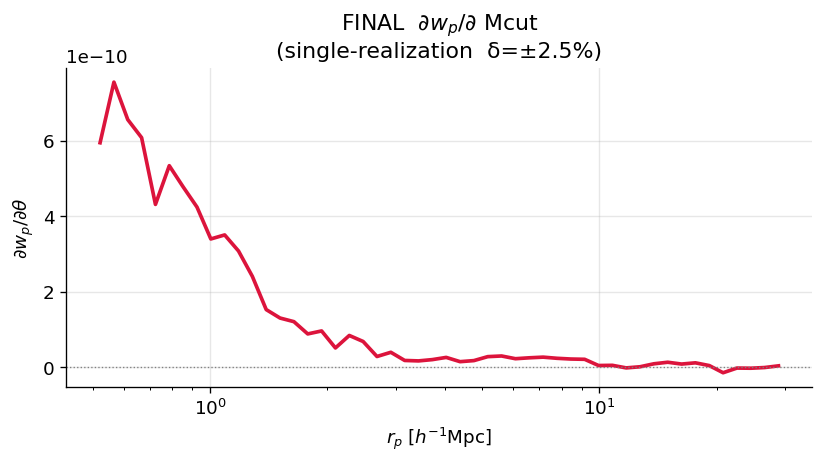

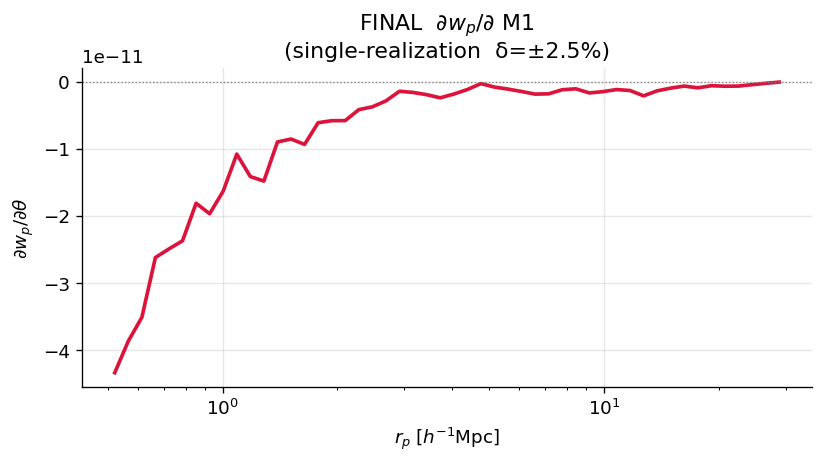

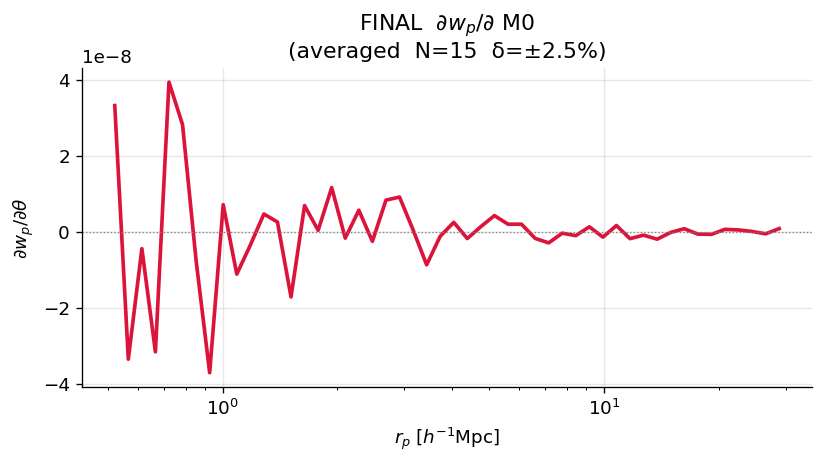

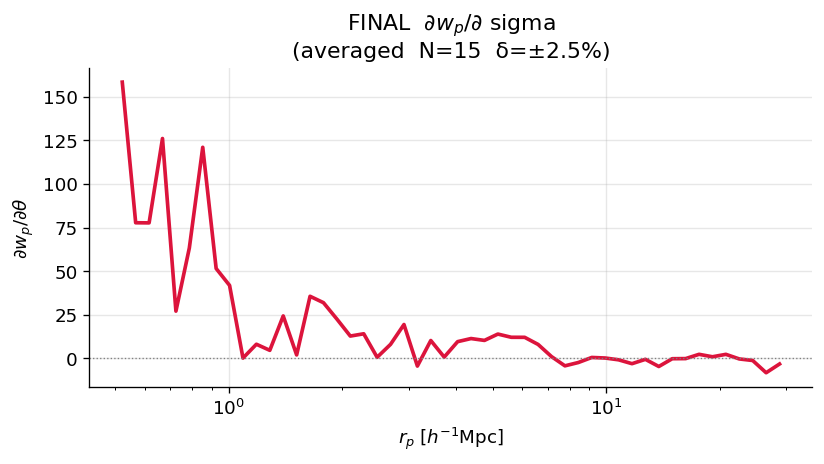

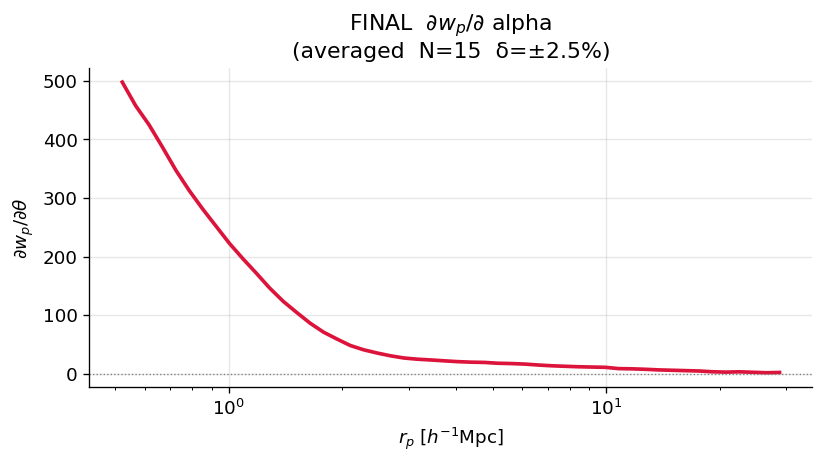


NOTEBOOK COMPLETE
  Halo catalogue  : Sahyadri default2048,  343,275 halos
  HOD model       : Smith et al. (2024) BGS, F_spline
  Mr threshold    : -18.0
  Galaxies (base) : 310,685
  Parameters      : ['Mcut', 'M1', 'M0', 'sigma', 'alpha']
  Output file     : results/wp_derivatives_Mr18_seed10.npz


In [18]:
FINAL_DERIVS = {}
FINAL_METHOD = {}

for param in HOD_PARAM_NAMES:
    if param in NOISY_PARAMS and 'derivs_averaged' in dir() and param in derivs_averaged:
        rp_ref, dwp_mean, _ = derivs_averaged[param]
        FINAL_DERIVS[param] = dwp_mean
        FINAL_METHOD[param] = f'averaged  N={N_REALIZATIONS}  δ=±{100*DELTA_STABLE:.1f}%'
    else:
        rp_ref, dwp_single  = derivs[param][0.025]
        FINAL_DERIVS[param] = dwp_single
        FINAL_METHOD[param] = 'single-realization  δ=±2.5%'

# ── Final derivative table ────────────────────────────────────
print('=' * 78)
print('FINAL DERIVATIVES   d(wp) / d(theta)')
print(f'Sample: Mr < {MR_THRESH},  seed = {SEED},  pimax = {PIMAX} h⁻¹ Mpc')
print('=' * 78)
print(f'Method per parameter:')
for param in HOD_PARAM_NAMES:
    print(f'  {param:<8} : {FINAL_METHOD[param]}')
print()

header = f"{'rp':>10}" + ''.join(f"  {p:>14}" for p in HOD_PARAM_NAMES)
print(header)
print('-' * len(header))
for b in range(N_RP):
    row = f"{rp_ref[b]:>10.4f}"
    for param in HOD_PARAM_NAMES:
        row += f"  {FINAL_DERIVS[param][b]:>14.4f}"
    print(row)

# ── Save to disk ──────────────────────────────────────────────
outfile = OUTPUT_DIR / f'wp_derivatives_Mr{abs(MR_THRESH):.0f}_seed{SEED}.npz'

save_dict = {
    'rp':        rp_ref,
    'wp_base':   wp_base,
    'rp_base':   rp_base,
    'seed':      np.int64(SEED),
    'Mr_thresh': np.float64(MR_THRESH),
    'pimax':     np.float64(PIMAX),
    'Lbox':      np.float64(LBOX),
}
for pname in HOD_PARAM_NAMES:
    save_dict[f'base_{pname}']             = np.float64(BASE_HOD[pname])
    save_dict[f'dwp_d{pname}_FINAL']       = FINAL_DERIVS[pname]
    save_dict[f'dwp_d{pname}_method']      = FINAL_METHOD[pname]
    for delta in [0.050, 0.025]:
        rp_d, dwp_d = derivs[pname][delta]
        save_dict[f'dwp_d{pname}_delta{int(1000*delta):03d}'] = dwp_d

np.savez(outfile, **save_dict)
print(f'\nSaved {len(save_dict)} arrays → {outfile}')

# ── Reload verification ───────────────────────────────────────
_chk = np.load(outfile, allow_pickle=True)
assert set(HOD_PARAM_NAMES).issubset(
    {k.split('dwp_d')[-1].split('_FINAL')[0] for k in _chk.files if 'FINAL' in k}
), 'Not all FINAL derivatives present in saved file'
print(f'Reload verification: all {len(HOD_PARAM_NAMES)} FINAL derivatives present ✓')

# ── Per-parameter FINAL derivative plots ─────────────────────
print()
for param in HOD_PARAM_NAMES:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(rp_ref, FINAL_DERIVS[param], color='crimson', lw=2.2)
    ax.axhline(0, color='gray', lw=0.8, ls=':')
    ax.set_xscale('log')
    ax.set_xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
    ax.set_ylabel(r'$\partial w_p / \partial\theta$')
    ax.set_title(f'FINAL  $\\partial w_p / \\partial$ {param}\n({FINAL_METHOD[param]})')
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

print()
print('=' * 70)
print('NOTEBOOK COMPLETE')
print('=' * 70)
print(f'  Halo catalogue  : Sahyadri default2048,  {halos.size:,} halos')
print(f'  HOD model       : Smith et al. (2024) BGS, F_spline')
print(f'  Mr threshold    : {MR_THRESH}')
print(f'  Galaxies (base) : {mock_base["ncen_total"]+mock_base["nsat_total"]:,}')
print(f'  Parameters      : {HOD_PARAM_NAMES}')
print(f'  Output file     : {outfile}')


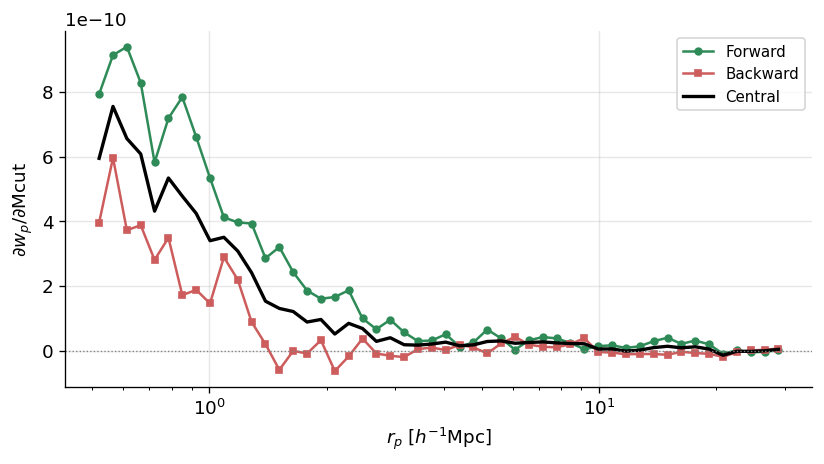

Mcut      max |forward-backward|/|central| = 22.242   median = 1.565


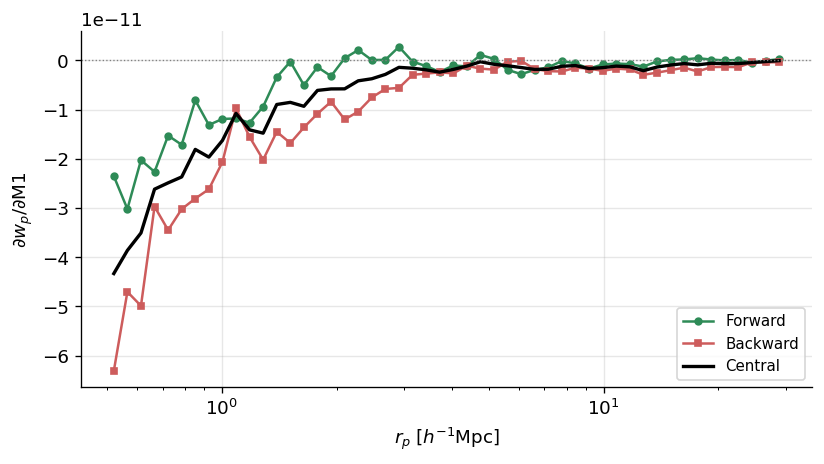

M1        max |forward-backward|/|central| = 9.254   median = 0.917


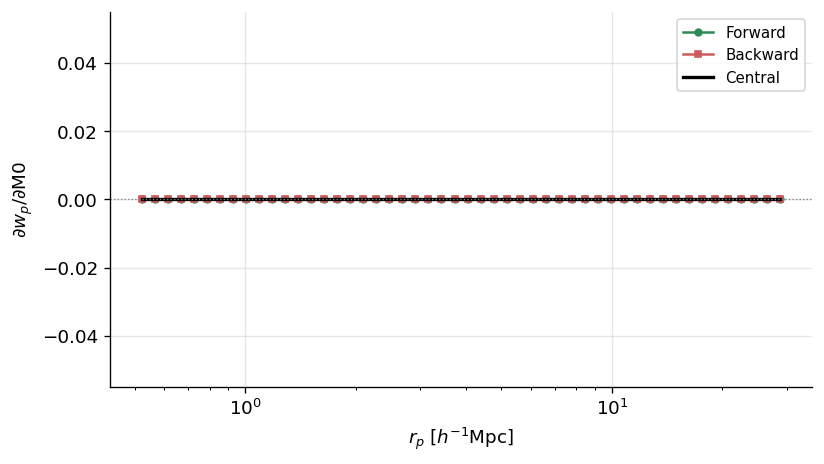

M0        max |forward-backward|/|central| = 0.000   median = 0.000


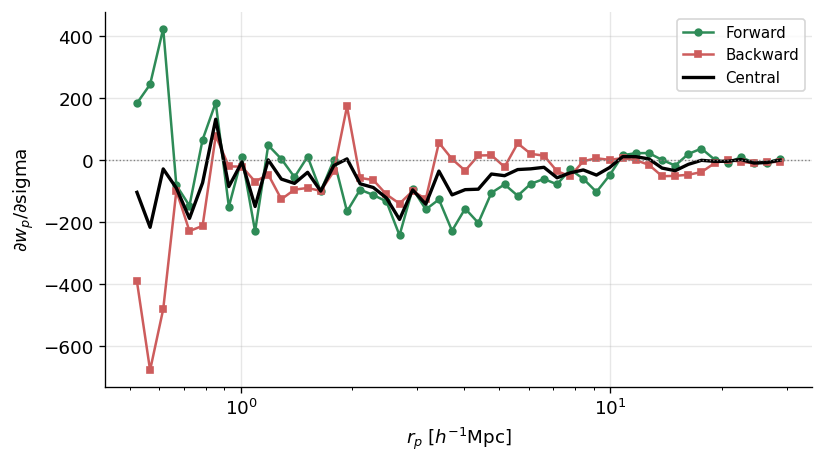

sigma     max |forward-backward|/|central| = 129.034   median = 2.073


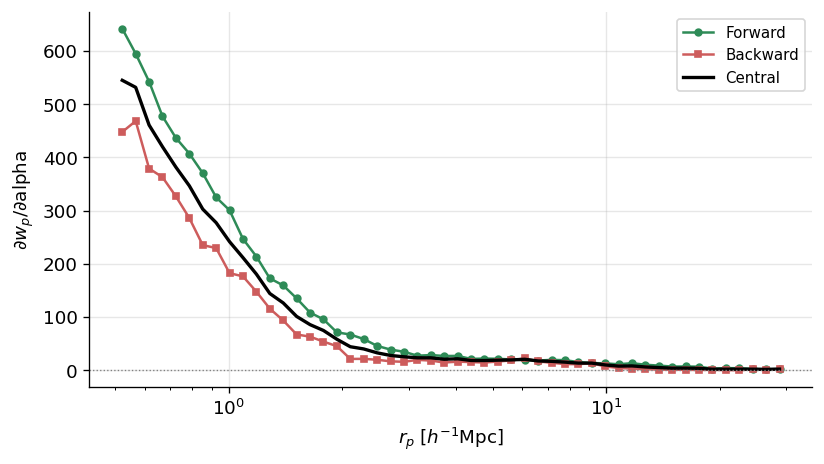

alpha     max |forward-backward|/|central| = 2.069   median = 0.460

Large spread (e.g. >0.5-1.0) at a given rp bin means forward/backward/central
meaningfully disagree there -- either real curvature in wp(theta), or the same
RNG-drift noise from Ch 11a still bleeding through a single realization.
For NOISY_PARAMS specifically, expect this to shrink once you swap in the
multi-seed-averaged wp_p/wp_m from Ch 11b instead of the single-realization ones.


In [19]:
# ============================================================
# Forward / Backward / Central comparison
#
# Same step h = theta_base * delta for all three, per parameter.
# forward  = (wp(theta+h) - wp(theta))     / h
# backward = (wp(theta)   - wp(theta-h))   / h
# central  = (wp(theta+h) - wp(theta-h))   / (2h)
#
# Reuses wp_base (Ch 8) and wp_results[param][delta] (Ch 11) --
# no new mock generation.
# ============================================================

CHECK_DELTA = 0.025   # which step size to run this diagnostic at

fd_comparison = {}

for param in HOD_PARAM_NAMES:
    rp_p, wp_p, wp_m = wp_results[param][CHECK_DELTA]
    h = BASE_HOD[param] * CHECK_DELTA        # single-sided step

    forward  = (wp_p    - wp_base) / h
    backward = (wp_base - wp_m)    / h
    central  = (wp_p    - wp_m)    / (2 * h)

    fd_comparison[param] = (rp_p, forward, backward, central)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(rp_p, forward,  'o-', ms=4, color='seagreen',  label='Forward')
    ax.plot(rp_p, backward, 's-', ms=4, color='indianred', label='Backward')
    ax.plot(rp_p, central,  '-',  lw=2, color='black',     label='Central')
    ax.axhline(0, color='gray', lw=0.8, ls=':')
    ax.set_xscale('log')
    ax.set_xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
    ax.set_ylabel(f'$\\partial w_p/\\partial${param}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    # Quantitative check: how far apart are forward and backward,
    # relative to the central estimate? Large values = curvature/noise
    # dominating over the linear-slope assumption at this step size.
    denom = np.maximum(np.abs(central), 1e-30)
    fb_spread = np.abs(forward - backward) / denom
    print(f"{param:<8}  max |forward-backward|/|central| = {np.max(fb_spread):.3f}   "
          f"median = {np.median(fb_spread):.3f}")

print("\nLarge spread (e.g. >0.5-1.0) at a given rp bin means forward/backward/central")
print("meaningfully disagree there -- either real curvature in wp(theta), or the same")
print("RNG-drift noise from Ch 11a still bleeding through a single realization.")
print("For NOISY_PARAMS specifically, expect this to shrink once you swap in the")
print("multi-seed-averaged wp_p/wp_m from Ch 11b instead of the single-realization ones.")

In [20]:
# ============================================================
# Catalogue persistence — save + reload mock_base
# (workflow addition only; no scientific logic changed)
# ============================================================

import pickle

# ── Directory setup ─────────────────────────────────────────
CATALOGUE_DIR = OUTPUT_DIR / "catalogues"
CATALOGUE_DIR.mkdir(parents=True, exist_ok=True)

# ── Filename encodes reproducibility info ───────────────────
# Format: mock_Mr{threshold}_seed{seed}_baseline.npz
# (use a different suffix instead of "baseline" for perturbed runs,
#  e.g. mock_Mr-18_seed10_lgMmin+5.npz)
_mr_tag = f"Mr{MR_THRESH:+.0f}".replace('+', '')  # e.g. "Mr-18"
catalogue_filename = f"mock_{_mr_tag}_seed{SEED}_baseline.npz"
catalogue_path = CATALOGUE_DIR / catalogue_filename

# ── Save catalogue ───────────────────────────────────────────
# Using np.savez_compressed (not pickle) because:
#   - all fields are plain numpy arrays / scalars, no custom objects
#   - npz is portable across numpy versions and readable without
#     unpickling arbitrary code (safer for shared/HPC filesystems)
#   - compression matters here since x/y/z/halo_idx/is_central
#     can be tens of millions of elements for full-box catalogues
print(f"Saving catalogue → {catalogue_path}")
np.savez_compressed(
    catalogue_path,
    x            = mock_base['x'],
    y            = mock_base['y'],
    z            = mock_base['z'],
    halo_idx     = mock_base['halo_idx'],
    is_central   = mock_base['is_central'],
    ncen_total   = np.int64(mock_base['ncen_total']),
    nsat_total   = np.int64(mock_base['nsat_total']),
)
assert catalogue_path.exists(), f"Save failed — file not found at {catalogue_path}"
print(f"✓ Catalogue saved  ({catalogue_path.stat().st_size / 1e6:.2f} MB)")

# ── Reload catalogue ─────────────────────────────────────────
print(f"Reloading catalogue ← {catalogue_path}")
_loaded = np.load(catalogue_path, allow_pickle=False)

reloaded_mock = {
    'x':          _loaded['x'],
    'y':          _loaded['y'],
    'z':          _loaded['z'],
    'halo_idx':   _loaded['halo_idx'],
    'is_central': _loaded['is_central'],
    'ncen_total': int(_loaded['ncen_total']),
    'nsat_total': int(_loaded['nsat_total']),
}
print("✓ Catalogue reloaded")

# ── Verify reloaded catalogue is identical to in-memory one ──
for field in ['x', 'y', 'z', 'halo_idx', 'is_central']:
    assert np.array_equal(mock_base[field], reloaded_mock[field]), \
        f"Mismatch in field '{field}' after reload!"

assert mock_base['ncen_total'] == reloaded_mock['ncen_total'], \
    "ncen_total mismatch after reload!"
assert mock_base['nsat_total'] == reloaded_mock['nsat_total'], \
    "nsat_total mismatch after reload!"

print("✓ Reloaded catalogue is identical to in-memory catalogue")
print()
print(f"  x/y/z arrays   : {reloaded_mock['x'].size:,} elements each, bit-identical")
print(f"  halo_idx       : {reloaded_mock['halo_idx'].size:,} elements, bit-identical")
print(f"  is_central     : {reloaded_mock['is_central'].size:,} elements, bit-identical")
print(f"  ncen_total     : {reloaded_mock['ncen_total']:,}")
print(f"  nsat_total     : {reloaded_mock['nsat_total']:,}")
print()
print(f"✓ Catalogue persistence validated — saved to '{catalogue_filename}'")
print("  Downstream cells (compute_wp, derivatives) continue to use")
print("  the original in-memory `mock_base` — this cell only adds a")
print("  disk checkpoint and does not alter any scientific object.")

Saving catalogue → results/catalogues/mock_Mr-18_seed10_baseline.npz
✓ Catalogue saved  (5.66 MB)
Reloading catalogue ← results/catalogues/mock_Mr-18_seed10_baseline.npz
✓ Catalogue reloaded
✓ Reloaded catalogue is identical to in-memory catalogue

  x/y/z arrays   : 310,685 elements each, bit-identical
  halo_idx       : 310,685 elements, bit-identical
  is_central     : 310,685 elements, bit-identical
  ncen_total     : 207,998
  nsat_total     : 102,687

✓ Catalogue persistence validated — saved to 'mock_Mr-18_seed10_baseline.npz'
  Downstream cells (compute_wp, derivatives) continue to use
  the original in-memory `mock_base` — this cell only adds a
  disk checkpoint and does not alter any scientific object.


Based on your file and the script provided in your code, here is a single Markdown document detailing all the mathematical formulations, functions, and statistical operations used throughout the pipeline.

---

# Mathematical Documentation: HOD Derivative & Mock Pipeline

This document outlines the mathematical formulations, probability functions, and numerical algorithms implemented in the project pipeline.

---

## 1. Cosmology & Background Mathematics

### 1.1 Dimensionless Hubble Parameter $E(z)$

For a flat $\Lambda\text{CDM}$ universe, the expansion rate as a function of redshift $z$ is given by:


$$E(z) = \frac{H(z)}{H_0} = \sqrt{\Omega_m(1+z)^3 + (1-\Omega_m)}$$


where $\Omega_m$ (`OMEGA_M`) is the matter density parameter.

### 1.2 Virial Radius and Density Threshold

The virial radius $R_{\text{vir}}$ for a halo of mass $M_{200b}$ is calculated using the mean-200 background density convention:


$$M = \frac{4\pi}{3} \Delta_{\text{vir}} \rho_{c}(z) R_{\text{vir}}^3$$

* **Critical Density at redshift zero ($\rho_c$):** $\rho_c = 2.7754 \times 10^{11} \, h^2 M_\odot \, \text{Mpc}^{-3}$.
* **Critical Density at redshift $z$:** $\rho_{c}(z) = \rho_c E(z)^2$.
* **Virial Density Threshold:** $\Delta_{\text{vir}} = 200 \times \Omega_m$.

---

## 2. Smith et al. (2024) DESI BGS HOD Model

The pipeline maps the r-band absolute magnitude threshold $M_r$ to five primary HOD parameters $\theta = \{M_{\text{cut}}, M_1, M_0, \sigma, \alpha\}$ using the 17 fitted coefficients from Smith et al. (2024). Let $x = M_r - M_{\text{pivot}}$ where $M_{\text{pivot}} = -20.0$.

### 2.1 Polynomial and Sigmoid Fits

* **$M_{\text{cut}}$ and $M_1$ (Cubic Polynomial):**

$$\log_{10} M(M_r) = (A + 12) + Bx + Cx^2 + Dx^3$$


* **$M_0$ (Linear Polynomial):**

$$\log_{10} M_0(M_r) = (A + 11) + Bx$$


* **$\sigma$ (Sigmoid Function):**

$$\sigma(M_r) = A_\sigma + \frac{B_\sigma - A_\sigma}{1 + \exp\left[C_\sigma(x + D_\sigma)\right]}$$


* **$\alpha$ (Power-Law Function):**

$$\alpha(M_r) = A_\alpha + B_\alpha^{(-x + C_\alpha)}$$


* **Derived Parameter $\kappa$:**

$$\kappa = \frac{M_0}{M_{\text{cut}}}$$



---

## 3. Occupation Statistics & Spline Kernel CDF

### 3.1 Central Occupation ($N_{\text{cen}}$)

Instead of a traditional Error Function ($\text{erf}$), the BGS model uses an analytic Cumulative Distribution Function (CDF) derived from a spline kernel, $F_{\text{spline}}(x)$:


$$\langle N_{\text{cen}} \rangle(M) = \frac{1}{2} \left[1 + F_{\text{spline}}(x)\right]$$


where the normalized mass argument is:


$$x = \frac{\log_{10} M - \log_{10} M_{\text{cut}}}{\sigma}$$

The piecewise formulation of $F_{\text{spline}}(t)$ where $t = \frac{x}{\sqrt{6}}$ is defined as:


$$F_{\text{spline}}(x) = \begin{cases}  \text{sign}(t) \left(\frac{8}{3}\vert{}t\vert{} - \frac{16}{3}\vert{}t\vert{}^3 + 4\vert{}t\vert{}^4\right) & \text{for } \vert{}t\vert{} \le 0.5 \\  \text{sign}(t) \left(1 - \frac{4}{3}(1 - \vert{}t\vert{})^4\right) & \text{for } 0.5 < \vert{}t\vert{} \le 1.0 \\  \text{sign}(t) \times 1.0 & \text{for } \vert{}t\vert{} > 1.0  \end{cases}$$

### 3.2 Satellite Occupation ($N_{\text{sat}}$)

The unconditional satellite expectation value is modeled as a threshold power-law gated by the central occupation:


$$\langle N_{\text{sat}} \rangle(M) = \langle N_{\text{cen}} \rangle(M) \cdot \left(\frac{M - \kappa M_{\text{cut}}}{M_1}\right)^\alpha \quad \text{for } M > \kappa M_{\text{cut}}$$


and zero otherwise.

---

## 4. Spatial Distribution: NFW Profile Sampling

Satellites are distributed isotropically around parent halos using the Navarro-Frenk-White (NFW) profile.

### 4.1 Enclosed Mass Function

The dimensionless enclosed mass fraction $M(<r)/M_{\text{total}}$ relies on the NFW mass profile function:


$$M_{\text{encl}}(x) = \ln(1+x) - \frac{x}{1+x}$$


where $x = \frac{r}{r_s}$ is the radial distance scaled by the scale radius $r_s = \frac{R_{\text{vir}}}{c}$, and $c$ is the halo concentration parameter ($c = R_{\text{vir}}/r_s$).

Radii $r$ are sampled using **inverse-transform sampling**:


$$P(x) = \frac{M_{\text{encl}}(x)}{M_{\text{encl}}(c)}$$


A uniform random deviate $u \in [0,1]$ maps to $x$ via linear interpolation: $x = P^{-1}(u)$, yielding $r = x \times r_s$.

---

## 5. Statistical Estimation & Derivative Engine

### 5.1 Projected Correlation Function $w_p(r_p)$

Clustering measurements are quantified using the projected correlation function via `Corrfunc`, integrating the 3D correlation function $\xi(r_p, \pi)$ along the line-of-sight up to $\pi_{\max} = 40.0 \, h^{-1}\text{Mpc}$:


$$w_p(r_p) = 2 \int_{0}^{\pi_{\max}} \xi(r_p, \pi) \, d\pi$$

### 5.2 Central Finite-Difference Derivatives

Parameter sensitivities for the Fisher information matrix are computed using central finite differences with dual step sizes ($\delta = 5\%$ and $\delta = 2.5\%$):


$$\frac{\partial w_p(r_p)}{\partial \theta_i} \approx \frac{w_p(\theta_i + \delta\theta_i) - w_p(\theta_i - \delta\theta_i)}{2\delta\theta_i}$$


where $\delta\theta_i = \delta \cdot \theta_i$.

### 5.3 Multi-Seed Ensemble Averaging

To eliminate the stochastic noise floor introduced by Poisson realization drift across perturbed parameters, final unstable parameters (e.g., $\sigma$, $\alpha$) are averaged across $N_{\text{realizations}} = 15$ independent seeds:


$$\left\langle \frac{\partial w_p}{\partial \theta_i} \right\rangle = \frac{1}{N} \sum_{s=1}^{N} \left[ \frac{w_p^{(s)}(\theta_i + \delta\theta_i) - w_p^{(s)}(\theta_i - \delta\theta_i)}{2\delta\theta_i} \right]$$